# Gastrulation dataset check
取得済みAnnDataの読取専用診断。annotation移植・追加前処理・学習・velocity・benchmark指標計算は行いません。

リモートで先に `python download_data.py` を実行し、このNotebookを上から順に実行してください。パス入力は不要です。`full` はscVelo取得データの呼称であり、内容は本Notebookで確認します。

In [1]:
from pathlib import Path
import sys
import importlib.metadata
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

candidates = []
for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([parent, parent / 'data_preparation' / '20261007'])
candidates.append(Path('/home/suzuki/Projects/scDiffusion-github/data_preparation/20261007'))
BASE = next((p.resolve() for p in candidates if (p / 'inspection_helpers.py').is_file()
             and (p / 'download_data.py').is_file()), None)
if BASE is None:
    raise FileNotFoundError('Notebookの配置ディレクトリまたはリポジトリからJupyterを起動してください。')
sys.path.insert(0, str(BASE))
from inspection_helpers import (SEED, CANDIDATES, matrices, structure, obs_report,
    id_report, compare_columns, describe_matrix, library_report, positions,
    bounded_subset, agreement, scatter, histogram)
DATA = BASE / 'data'
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)
print('BASE:', BASE, '\nDATA:', DATA, '\nFIGURES:', FIGURES)
print({p: importlib.metadata.version(p) for p in
       ['anndata', 'scanpy', 'scvelo', 'numpy', 'scipy', 'pandas', 'matplotlib', 'h5py']})
for name in ['gastrulation_full.h5ad', '03_Gastrulation_erythroid.h5ad']:
    if not (DATA / name).is_file():
        raise FileNotFoundError(f'{DATA / name}: リモートで先にdownload_data.pyを実行してください。')
full = sc.read_h5ad(DATA / 'gastrulation_full.h5ad')
ery = sc.read_h5ad(DATA / '03_Gastrulation_erythroid.h5ad')
datasets = {'full': full, 'ery': ery}

BASE: /home/suzuki/Projects/scDiffusion-github/data_preparation/20261007 
DATA: /home/suzuki/Projects/scDiffusion-github/data_preparation/20261007/data 
FIGURES: /home/suzuki/Projects/scDiffusion-github/data_preparation/20261007/figures
{'anndata': '0.8.0', 'scanpy': '1.9.3', 'scvelo': '0.3.3', 'numpy': '1.26.4', 'scipy': '1.13.1', 'pandas': '2.3.3', 'matplotlib': '3.9.4', 'h5py': '3.8.0'}


## A. AnnData全体構造と各matrixの統計
Xと全layersを走査します。全matrixのdense化はありません。基本momentsは全要素、quantileは推定値です。`.raw` の存在とshapeも確認しますが、名前だけではraw countとは決めません。

In [2]:
diagnostics = {}
for name, adata in datasets.items():
    print('\n===', name, '===')
    structure(adata)
    diagnostics[name] = {}
    for key, matrix in matrices(adata):
        print('Scanning:', name, key, matrix.shape, flush=True)
        diagnostics[name][key] = describe_matrix(matrix)
    display(pd.DataFrame({k: v['summary'] for k, v in diagnostics[name].items()}).T)


=== full ===
AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
obs ['barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_ve

,shape,dtype,storage,min,max,mean,variance,nonfinite_count,nonzero_fraction_finite,zero_fraction_finite,...,has_negative,median_estimate,quantile_sample_n,nonzero_sample_n,integer_like_fraction,fractional_fraction,q0.5_estimate,q0.9_estimate,q0.99_estimate,q0.999_estimate
X,"(89267, 53801)",float32,sparse,0,4855.0,0.219327,8.321921,0,0.055351,0.944649,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,28.0
spliced,"(89267, 53801)",float32,sparse,0,4855.0,0.219327,8.321921,0,0.055351,0.944649,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,28.0
unspliced,"(89267, 53801)",float32,sparse,0,157.0,0.01326,0.055149,0,0.009443,0.990557,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,0.0,2.0



=== ery ===
AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'stage', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw_counts', 'spliced', 'unspliced'
obs ['stage', 'celltype']
var []
layers ['raw_counts', 'spliced', 'unspliced']
obsm ['X_pca', 'X_umap']
varm []
obsp []
uns []
raw: None
Count-named layers (names alone do not prove raw counts): ['raw_counts']
X_pca (9815, 50)
X_umap (9815, 2)
Scanning: ery X (9815, 53801)
Scanning: ery raw_counts (9815, 53801)
Scanning: ery spliced (9815, 53801)
Scanning: ery unspliced (9815, 53801)


,shape,dtype,storage,min,max,mean,variance,nonfinite_count,nonzero_fraction_finite,zero_fraction_finite,...,has_negative,median_estimate,quantile_sample_n,nonzero_sample_n,integer_like_fraction,fractional_fraction,q0.5_estimate,q0.9_estimate,q0.99_estimate,q0.999_estimate
X,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
raw_counts,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
spliced,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
unspliced,"(9815, 53801)",float32,sparse,0,120.0,0.012089,0.054292,0,0.008488,0.991512,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,0.0,2.0


## B. obsの全column・候補annotation

In [3]:
for name, adata in datasets.items():
    print('\n===', name, 'OBS ===')
    obs_report(adata.obs)


=== full OBS ===


,barcode,sample,stage,sequencing.batch,theiler,doub.density,doublet,cluster,cluster.sub,cluster.stage,...,haem_subclust,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,cell_velocyto_loom
index,,,,,,,,,,,,,,,,,,,,,
cell_1,AAAGGCCTCCACAA,1,E6.5,1,TS9,0.043114,False,2.0,4.0,2.0,...,nan,NaN,NaN,nan,NaN,NaN,NaN,NaN,nan,possorted_genome_bam_7SUA3:AAAGGCCTCCACAAx
cell_2,AACAAACTCGCCTT,1,E6.5,1,TS9,1.129713,False,12.0,1.0,1.0,...,nan,NaN,NaN,nan,NaN,NaN,NaN,NaN,nan,possorted_genome_bam_7SUA3:AACAAACTCGCCTTx
cell_6,AACATATGAATCGC,1,E6.5,1,TS9,1.254709,False,1.0,1.0,3.0,...,nan,NaN,NaN,nan,NaN,NaN,NaN,NaN,nan,possorted_genome_bam_7SUA3:AACATATGAATCGCx
cell_8,AACCGATGGCTTCC,1,E6.5,1,TS9,1.345759,False,2.0,1.0,2.0,...,nan,NaN,NaN,nan,NaN,NaN,NaN,NaN,nan,possorted_genome_bam_7SUA3:AACCGATGGCTTCCx
cell_9,AACGTGTGCTCTAT,1,E6.5,1,TS9,1.146369,False,2.0,1.0,2.0,...,nan,NaN,NaN,nan,NaN,NaN,NaN,NaN,nan,possorted_genome_bam_7SUA3:AACGTGTGCTCTATx


,column,dtype,unique,missing
0,barcode,category,84177,0
1,sample,int64,34,0
2,stage,category,9,0
3,sequencing.batch,int64,3,0
4,theiler,category,4,0
5,doub.density,float64,81446,0
6,doublet,bool,1,0
7,cluster,float64,16,0
8,cluster.sub,float64,10,0
9,cluster.stage,float64,22,0



 barcode 
categories: ['AAACATACAAGGCG', 'AAACATACACACAC', 'AAACATACACCTCC', 'AAACATACACGGGA', 'AAACATACACGTAC', 'AAACATACACGTTG', 'AAACATACATCGAC', 'AAACATACATTGGC', 'AAACATACCACTGA', 'AAACATACCAGATC', 'AAACATACCAGGAG', 'AAACATACCATGCA', 'AAACATACCCGTTC', 'AAACATACCCTTTA', 'AAACATACCGGTAT', 'AAACATACCTCGAA', 'AAACATACCTGACA', 'AAACATACCTGAGT', 'AAACATACCTTCTA', 'AAACATACGACAGG', 'AAACATACGAGCAG', 'AAACATACGATACC', 'AAACATACGCATCA', 'AAACATACGCGAGA', 'AAACATACGGTACT', 'AAACATACGGTTTG', 'AAACATACGTACAC', 'AAACATACGTCATG', 'AAACATACGTCGAT', 'AAACATACGTGCAT', 'AAACATACGTGTTG', 'AAACATACGTTTCT', 'AAACATACTAAGCC', 'AAACATACTACAGC', 'AAACATACTCAGGT', 'AAACATACTCGATG', 'AAACATACTCGTTT', 'AAACATACTGAGCT', 'AAACATACTGATGC', 'AAACATACTGCACA', 'AAACATACTGCTTT', 'AAACATACTTCTTG', 'AAACATACTTGACG', 'AAACATACTTGTCT', 'AAACATACTTTACC', 'AAACATTGAAAGCA', 'AAACATTGAACAGA', 'AAACATTGAAGAGT', 'AAACATTGAAGGGC', 'AAACATTGACACCA', 'AAACATTGACCTGA', 'AAACATTGACGGAG', 'AAACATTGAGCAAA', 'AAACATTGAGCCTA', 'AAA

barcode
TTAACCACGTTGGT    4
TGATCGGACGGAGA    4
TATACAGATTCGTT    3
TTCAAGCTCCTCAC    3
TTAGGGTGTCTAGG    3
CGAGATTGAACCGT    3
TTGACACTTTCTGT    3
GAAGGTCTTTCTTG    3
AATTGATGATCGAC    3
AGTACGTGCGTTGA    3
TATTTCCTTTCCCG    3
TGCGATGATGGCAT    3
CAGCCTTGTGTCCC    3
CGTGAAACCCGTAA    3
AGAGGTCTGGTGAG    3
GGATGTTGGTACGT    3
TATCCTGAGCCTTC    3
GGCCACGAGAGCTT    3
TTGCTATGGTACCA    3
AGCCAATGTTTCAC    3
GTGATCGACCTACC    3
GTAGTGTGTGCGTA    3
CAATAATGATCGGT    3
CTCGCATGTTTCAC    3
ATGCTTTGTTGTCT    3
GGGCACACGACGGA    3
CTTTGATGGGCGAA    3
GATAGAGATTGCGA    3
TGCGATGAACGCTA    3
AGTTTCACTCAGAC    3
Name: count, dtype: int64

...


 stage (annotation candidate)
categories: ['E7.0', 'E7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5']


stage
E8.5     3021
E8.0     2811
E7.75    1709
E8.25    1695
E7.5      471
E7.25      65
E7.0       43
Name: count, dtype: int64


 celltype (annotation candidate)
categories: ['Blood progenitors 1', 'Blood progenitors 2', 'Erythroid1', 'Erythroid2', 'Erythroid3']


celltype
Erythroid1             2929
Erythroid3             2697
Blood progenitors 2    2460
Erythroid2             1106
Blood progenitors 1     623
Name: count, dtype: int64

Absent candidates: ['clusters', 'sample', 'theiler', 'sequencing.batch']


## C. cell IDの対応
ID文字列は加工しません。重複を報告し、一意対応するIDだけを以後の値比較に使います。

In [4]:
print('full.obs_names:', full.obs_names)
print('ery.obs_names:', ery.obs_names)
cell_match, common_ids, aligned_cells = id_report(full.obs_names, ery.obs_names, 'cells')
ery_only_ids = ery.obs_names.unique().difference(full.obs_names.unique(), sort=False)
full_only_ids = full.obs_names.unique().difference(ery.obs_names.unique(), sort=False)

full.obs_names: Index(['cell_1', 'cell_2', 'cell_6', 'cell_8', 'cell_9', 'cell_10', 'cell_11',
       'cell_12', 'cell_13', 'cell_14',
       ...
       'cell_139321', 'cell_139322', 'cell_139323', 'cell_139324',
       'cell_139325', 'cell_139326', 'cell_139327', 'cell_139329',
       'cell_139330', 'cell_139331'],
      dtype='object', name='index', length=89267)
ery.obs_names: Index(['AAAGATCTCTCGAA', 'AATCTCACTGCTTT', 'AATGGCTGAAGATG', 'ACACATCTGTCAAC',
       'ACGACAACTGGAGG', 'ACTCCCGAGTCACA', 'ATCCAGGATGCATG', 'CAACAGACGGTACT',
       'CAGCTAGAATCGTG', 'CATTTGTGTGAGGG',
       ...
       'TTGCTATGGAGCTT', 'TTGGAGACGTCGAT', 'TTGGAGTGCAACCA', 'TTGTAGCTTACTCT',
       'TTTATCCTGTCACA', 'TTTCACGACTGGTA', 'TTTCAGTGCGAGTT', 'TTTCGAACGGTGAG',
       'TTTCGAACTAACCG', 'TTTCTACTTCTCTA'],
      dtype='object', length=9815)


axis                           cells
full_count                     89267
ery_count                       9815
full_unique                    89267
ery_unique                      9815
full_duplicate_extra_rows          0
ery_duplicate_extra_rows           0
full_has_duplicates            False
ery_has_duplicates             False
common_unique                      0
ery_coverage_common_over_n       0.0
full_coverage_common_over_n      0.0
ery_row_membership_fraction      0.0
ery_only_unique                 9815
full_only_unique               89267
same_order                     False
unambiguous_common                 0
dtype: object

ery coverage in full = common unique IDs / ery rows = 0.0
With duplicate IDs, this differs from row membership fraction.
common_ids []
ery_only_ids ['AAAGATCTCTCGAA', 'AATCTCACTGCTTT', 'AATGGCTGAAGATG', 'ACACATCTGTCAAC', 'ACGACAACTGGAGG', 'ACTCCCGAGTCACA', 'ATCCAGGATGCATG', 'CAACAGACGGTACT', 'CAGCTAGAATCGTG', 'CATTTGTGTGAGGG', 'CCAGACCTGACAGG', 'CCTATTGAGACGTT', 'CGAGAACTGATAAG', 'CGCTCATGTATCTC', 'CTGAGAACGTTGCA', 'GGAAGGACTCTTCA', 'GGTCAAACCTAGCA', 'TACTAAGAATCACG', 'TGGACTGAGAATCC', 'TGTGAGACCGTCTC']
full_only_ids ['cell_1', 'cell_2', 'cell_6', 'cell_8', 'cell_9', 'cell_10', 'cell_11', 'cell_12', 'cell_13', 'cell_14', 'cell_15', 'cell_17', 'cell_18', 'cell_21', 'cell_22', 'cell_23', 'cell_24', 'cell_26', 'cell_27', 'cell_28']


## D. 共通obs columnの対応
一致率は双方nonmissingのcell上で計算します。celltype/stageを正解と決めず、全共通columnを確認します。

In [5]:
common_obs_columns = full.obs.columns.intersection(ery.obs.columns, sort=False)
obs_agreement = compare_columns(full.obs, ery.obs, aligned_cells)
for col in CANDIDATES:
    if col in obs_agreement.index:
        print('Candidate:', col)
        display(obs_agreement.loc[col])
    else:
        print(col, ': not comparable / not shared')

COMMON COLUMNS: ['stage', 'celltype']
No unambiguous shared IDs; column comparisons skipped.
celltype : not comparable / not shared
clusters : not comparable / not shared
stage : not comparable / not shared
sample : not comparable / not shared
theiler : not comparable / not shared
sequencing.batch : not comparable / not shared


## E. gene IDの対応・共通var metadata

In [6]:
gene_match, common_genes, aligned_genes = id_report(full.var_names, ery.var_names, 'genes')
var_agreement = compare_columns(full.var, ery.var, aligned_genes, crosstabs=False)

axis                           genes
full_count                     53801
ery_count                      53801
full_unique                    53801
ery_unique                     53801
full_duplicate_extra_rows          0
ery_duplicate_extra_rows           0
full_has_duplicates            False
ery_has_duplicates             False
common_unique                  53801
ery_coverage_common_over_n       1.0
full_coverage_common_over_n      1.0
ery_row_membership_fraction      1.0
ery_only_unique                    0
full_only_unique                   0
same_order                      True
unambiguous_common             53801
dtype: object

ery coverage in full = common unique IDs / ery rows = 1.0
With duplicate IDs, this differs from row membership fraction.
common_ids ['Xkr4', 'Gm37180', 'Gm37363', 'Gm37686', 'Gm37329', 'Gm38148', 'Gm19938', 'Gm27396', 'Gm37381', 'Rp1', 'Gm6101', 'Gm37483', 'Sox17', 'Gm38076', 'Gm37323', 'Gm6085', 'Gm6119', 'Gm25493', 'Gm2053', 'Mrpl15']
ery_only_ids []
full_only_ids []
COMMON COLUMNS: []


""


## F. preprocessing状態の診断
整数らしさ、負値、値域、library size、metadataを観察します。これだけでraw/normalized/log1pを断定しません。quantileはゼロを含む座標sample、整数らしさはnonzero sampleです。

以後の発現比較は両datasetで一意に対応するcell/geneから固定seedで最大500×500を抽出し、同じ順序で参照します。

In [7]:
for name, entries in diagnostics.items():
    print('\n', name, 'X / all layers: preprocessing evidence')
    display(pd.DataFrame({k: v['summary'] for k, v in entries.items()}).T)
    display(pd.DataFrame({k: library_report(v['library']) for k, v in entries.items()
                          if k in ['X', 'spliced', 'unspliced']}).T)

rng = np.random.default_rng(SEED)
sampled_cells = aligned_cells.take(rng.choice(len(aligned_cells), min(500, len(aligned_cells)), replace=False))
sampled_genes = aligned_genes.take(rng.choice(len(aligned_genes), min(500, len(aligned_genes)), replace=False))
print('Matched sample shape:', len(sampled_cells), len(sampled_genes))
print('Sample cell IDs:', sampled_cells[:20].tolist())
print('Sample gene IDs:', sampled_genes[:20].tolist())
subsets = {name: {} for name in datasets}
if len(sampled_cells) and len(sampled_genes):
    for name, adata in datasets.items():
        ri = positions(adata.obs_names, sampled_cells)
        ci = positions(adata.var_names, sampled_genes)
        assert adata.obs_names.take(ri).equals(sampled_cells)
        assert adata.var_names.take(ci).equals(sampled_genes)
        for key, matrix in matrices(adata):
            if key in ['X', 'spliced', 'unspliced']:
                subsets[name][key] = bounded_subset(matrix, ri, ci)
        local = subsets[name]
        if 'X' in local and 'spliced' in local:
            print(name, 'X vs spliced')
            display(pd.Series(agreement(local['X'], local['spliced'])))
            if 'unspliced' in local:
                print(name, 'X vs spliced + unspliced')
                display(pd.Series(agreement(local['X'], local['spliced'] + local['unspliced'])))
else:
    print('No unambiguous matched cell/gene subset; paired expression diagnostics skipped.')


 full X / all layers: preprocessing evidence


,shape,dtype,storage,min,max,mean,variance,nonfinite_count,nonzero_fraction_finite,zero_fraction_finite,...,has_negative,median_estimate,quantile_sample_n,nonzero_sample_n,integer_like_fraction,fractional_fraction,q0.5_estimate,q0.9_estimate,q0.99_estimate,q0.999_estimate
X,"(89267, 53801)",float32,sparse,0,4855.0,0.219327,8.321921,0,0.055351,0.944649,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,28.0
spliced,"(89267, 53801)",float32,sparse,0,4855.0,0.219327,8.321921,0,0.055351,0.944649,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,28.0
unspliced,"(89267, 53801)",float32,sparse,0,157.0,0.01326,0.055149,0,0.009443,0.990557,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,0.0,2.0


,n,nonfinite,mean,std,median,q0,q0.01,q0.1,q0.5,q0.9,q0.99,q1
X,89267.0,0.0,11799.990097,4497.966217,11288.0,3676.0,4199.0,6496.6,11288.0,17492.0,25560.34,63680.0
spliced,89267.0,0.0,11799.990097,4497.966217,11288.0,3676.0,4199.0,6496.6,11288.0,17492.0,25560.34,63680.0
unspliced,89267.0,0.0,713.394479,303.340249,667.0,72.0,208.0,392.0,667.0,1074.0,1759.00,3565.0



 ery X / all layers: preprocessing evidence


,shape,dtype,storage,min,max,mean,variance,nonfinite_count,nonzero_fraction_finite,zero_fraction_finite,...,has_negative,median_estimate,quantile_sample_n,nonzero_sample_n,integer_like_fraction,fractional_fraction,q0.5_estimate,q0.9_estimate,q0.99_estimate,q0.999_estimate
X,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
raw_counts,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
spliced,"(9815, 53801)",float32,sparse,0,4855.0,0.240828,31.550601,0,0.051803,0.948197,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,4.0,37.0
unspliced,"(9815, 53801)",float32,sparse,0,120.0,0.012089,0.054292,0,0.008488,0.991512,...,False,0.0,100000,100000,1.0,0.0,0.0,0.0,0.0,2.0


,n,nonfinite,mean,std,median,q0,q0.01,q0.1,q0.5,q0.9,q0.99,q1
X,9815.0,0.0,12956.784310,4396.957319,12548.0,3733.0,4482.68,7664.0,12548.0,18881.6,25036.16,35274.0
spliced,9815.0,0.0,12956.784310,4396.957319,12548.0,3733.0,4482.68,7664.0,12548.0,18881.6,25036.16,35274.0
unspliced,9815.0,0.0,650.398268,223.824619,629.0,100.0,214.14,401.0,629.0,916.0,1375.58,2522.0


Matched sample shape: 0 500
Sample cell IDs: []
Sample gene IDs: ['1700025H01Rik', 'Gm42788', 'Gpr88', 'Vdac2', 'Mmp20', 'Gm24261', 'Gm24970', 'Tns1', 'Gm48644', 'Dynlrb1', 'Gm44828', 'Gm18301', 'Tmub1', 'Gm47228', 'Snx18', 'Usb1', 'Kmo', 'Gm10228', 'Zfp605', 'Fam187a']
No unambiguous matched cell/gene subset; paired expression diagnostics skipped.


## G. 同一cell・geneの発現値比較
順序を揃えたsubset上の比較です。差異があっても停止しません。sampleでの完全一致は全データでの完全一致を証明しません。

In [8]:
expression_agreement = {}
for key in ['X', 'spliced', 'unspliced']:
    if key in subsets['full'] and key in subsets['ery']:
        expression_agreement[key] = agreement(subsets['full'][key], subsets['ery'][key])
        print(key)
        display(pd.Series(expression_agreement[key]))
    else:
        print(key, ': missing matrix or no matched sample; skipped')

X : missing matrix or no matched sample; skipped
spliced : missing matrix or no matched sample; skipped
unspliced : missing matrix or no matched sample; skipped


## H. 発現量の可視化
PNGを `figures/` に保存します。gene統計は全cellから計算済みの値を使用します。scatterは最大50,000点。対数図は正値のみを表示します。nonzeroヒストグラムはsample分布です。

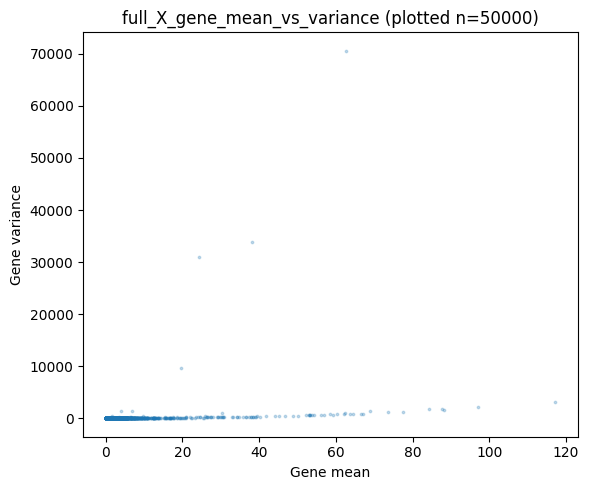

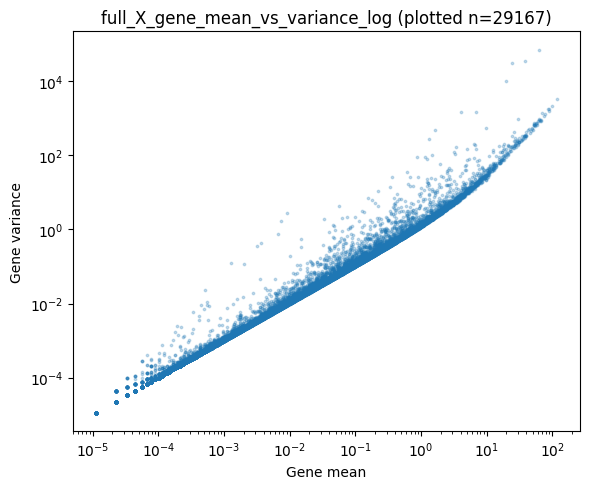

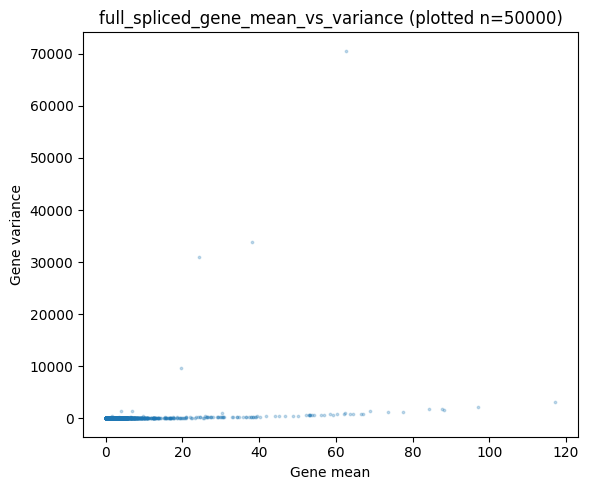

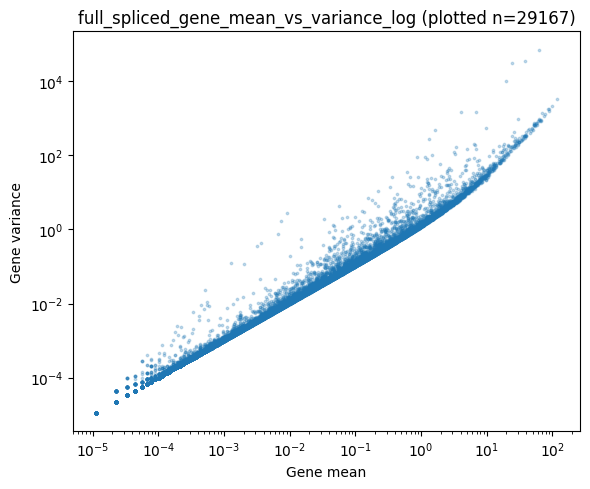

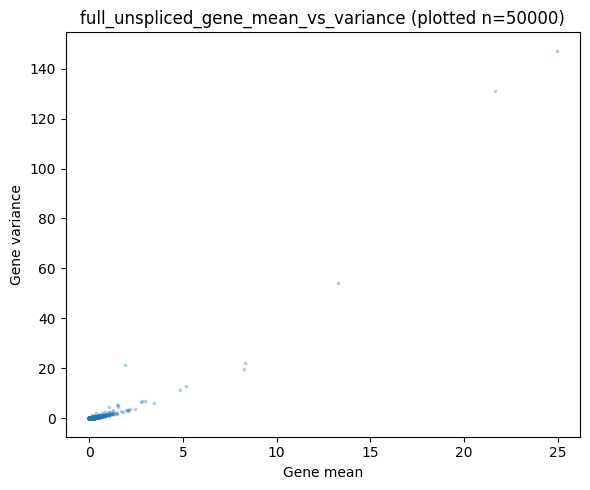

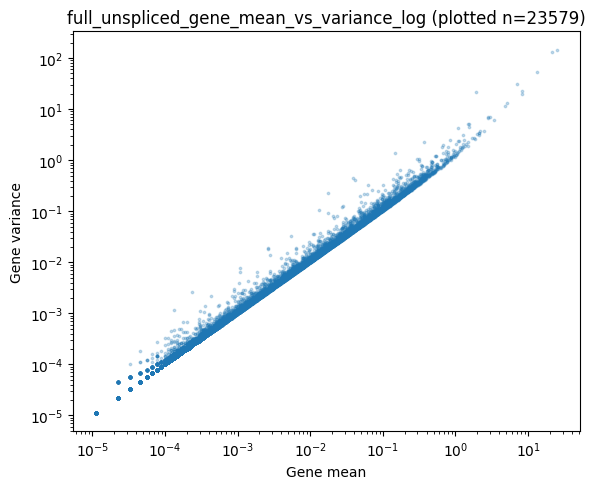

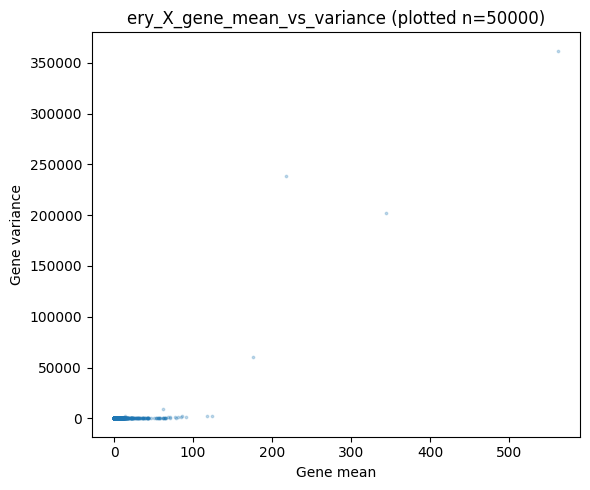

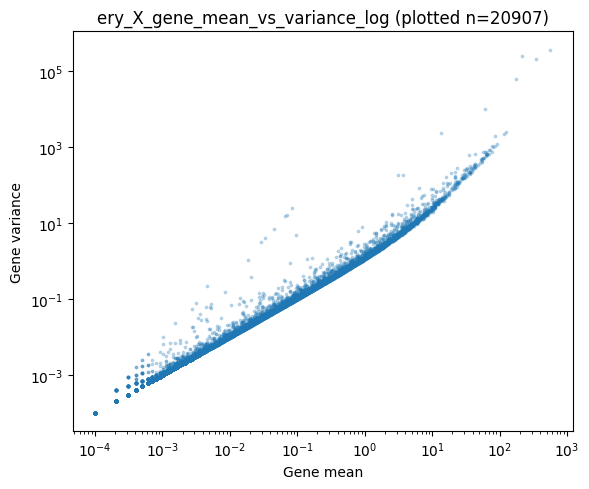

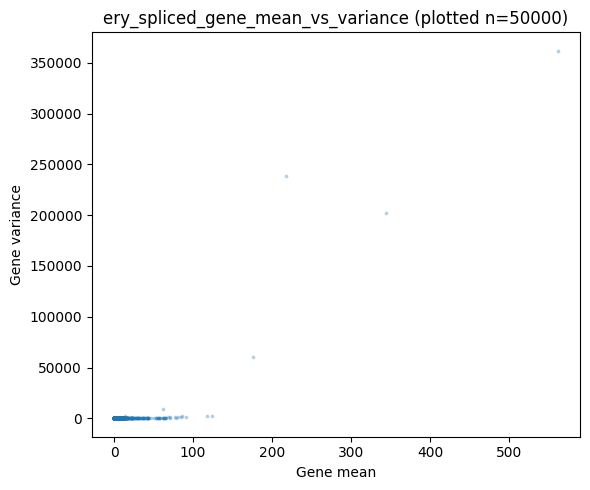

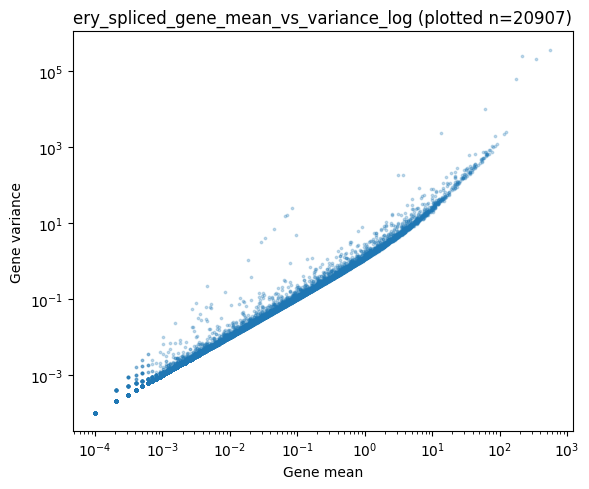

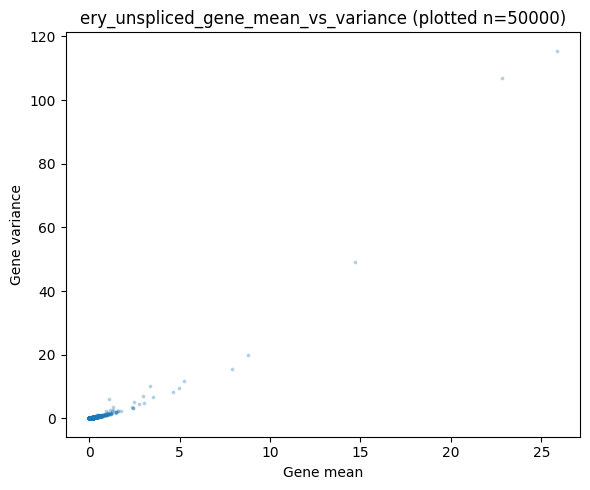

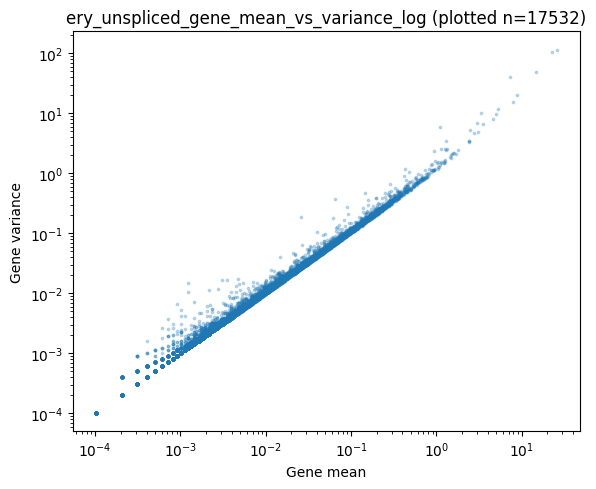

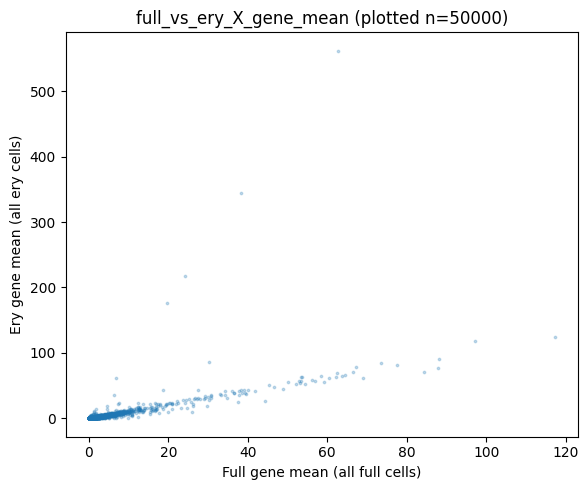

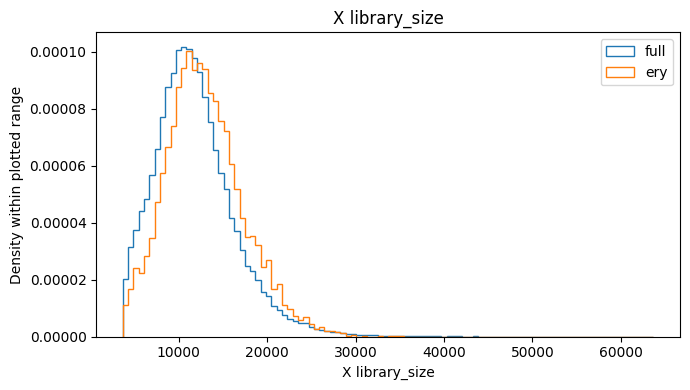

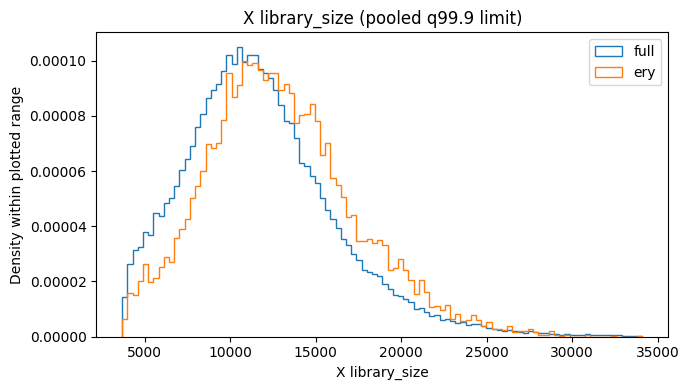

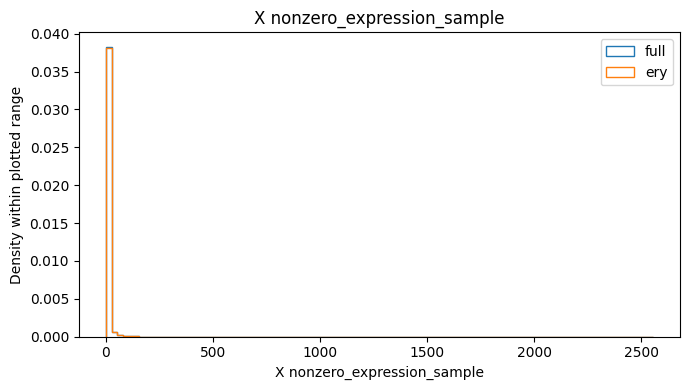

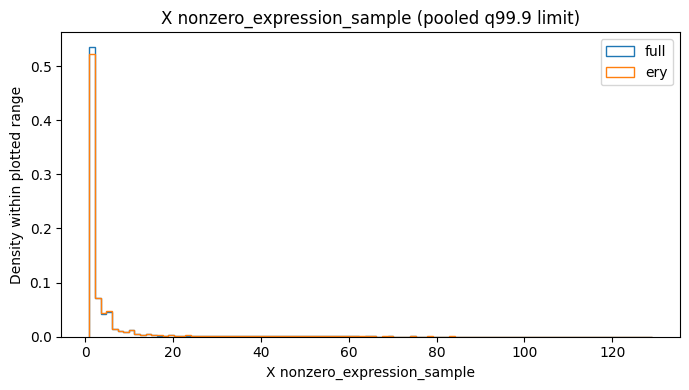

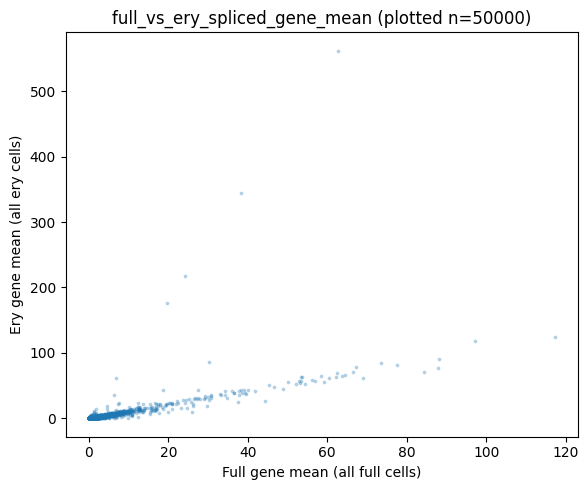

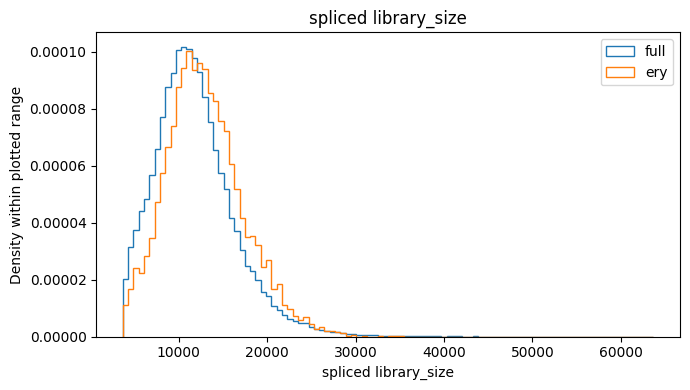

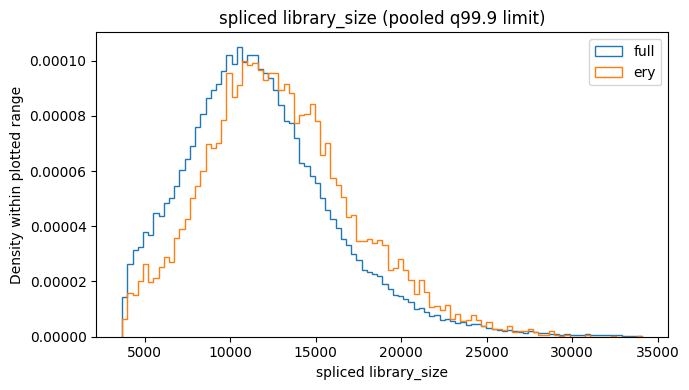

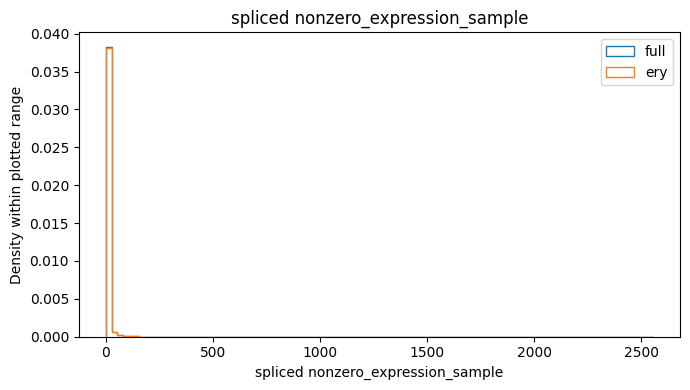

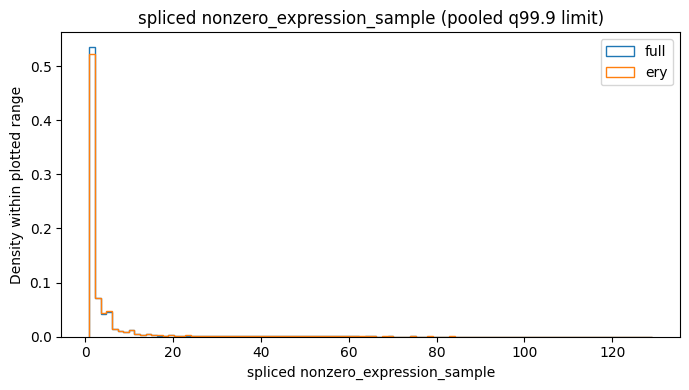

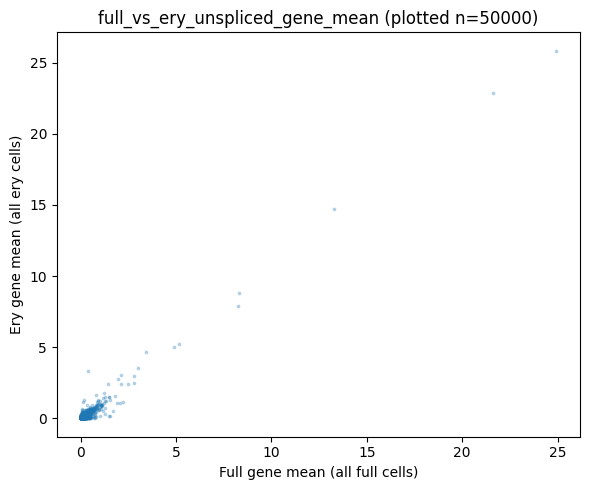

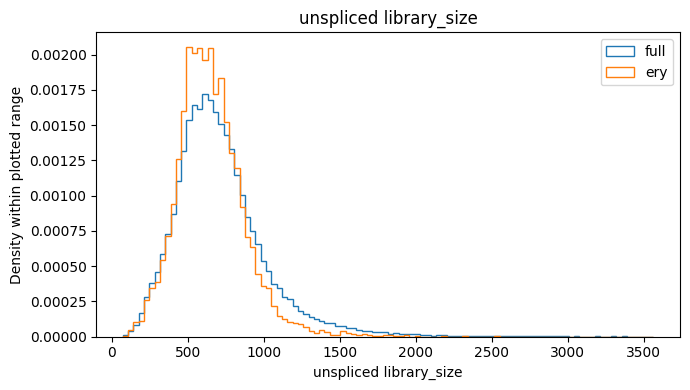

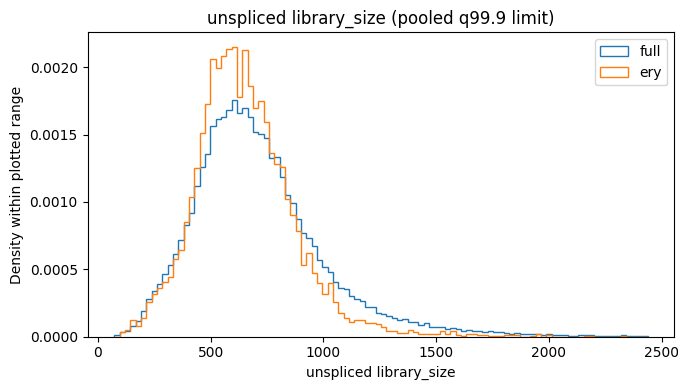

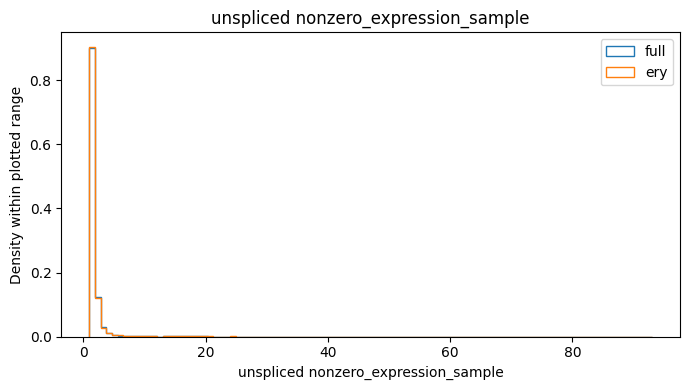

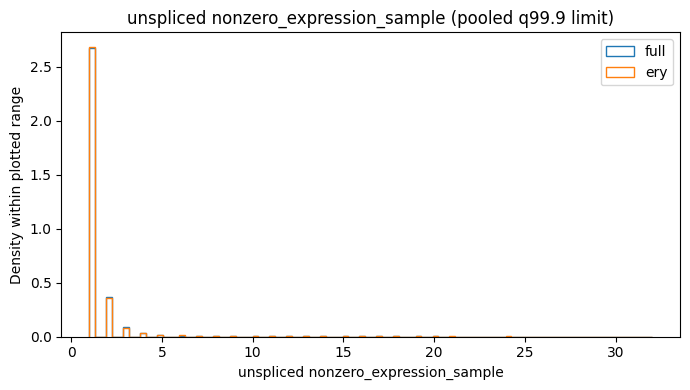

In [9]:
for name, entries in diagnostics.items():
    for key in ['X', 'spliced', 'unspliced']:
        if key not in entries:
            continue
        d = entries[key]
        for log in [False, True]:
            suffix = '_log' if log else ''
            scatter(d['gene_mean'], d['gene_var'], 'Gene mean', 'Gene variance',
                    FIGURES / f'{name}_{key}_gene_mean_vs_variance{suffix}.png', log=log)

for key in ['X', 'spliced', 'unspliced']:
    if all(key in diagnostics[name] for name in datasets) and len(aligned_genes):
        fi = positions(full.var_names, aligned_genes)
        ei = positions(ery.var_names, aligned_genes)
        assert full.var_names.take(fi).equals(ery.var_names.take(ei))
        scatter(diagnostics['full'][key]['gene_mean'][fi], diagnostics['ery'][key]['gene_mean'][ei],
                'Full gene mean (all full cells)', 'Ery gene mean (all ery cells)',
                FIGURES / f'full_vs_ery_{key}_gene_mean.png')
    if key in expression_agreement:
        scatter(subsets['full'][key], subsets['ery'][key], 'Full expression', 'Ery expression',
                FIGURES / f'matched_{key}_expression.png')
    for field, title in [('library', 'library_size'), ('nonzero_sample', 'nonzero_expression_sample')]:
        series = {name: entries[key][field] for name, entries in diagnostics.items() if key in entries}
        for clipped in [False, True]:
            suffix = '_q999' if clipped else ''
            histogram(series, f'{key} {title}', FIGURES / f'{key}_{title}{suffix}.png', clipped)

## I. 自動summary
データに対する変更・annotation採用の最終判断は行いません。

In [10]:
for name, adata in datasets.items():
    print('\n', name.upper())
    print('shape:', adata.shape)
    print('obs columns:', adata.obs.columns.tolist())
    print('layers:', list(adata.layers.keys()))
    for key in ['X', 'spliced', 'unspliced']:
        info = diagnostics[name].get(key)
        if info is None:
            print(key, ': absent')
        else:
            s = info['summary']
            print(key, ':', {k: s[k] for k in ['storage', 'dtype', 'integer_like_fraction',
                                               'min', 'max', 'zero_fraction_finite']})
print('\nCELL MATCH'); display(pd.Series(cell_match))
print('\nGENE MATCH'); display(pd.Series(gene_match))
print('\nCOMMON OBS COLUMNS:', common_obs_columns.tolist())
for col in ['celltype', 'stage']:
    print(col, 'agreement:')
    display(obs_agreement.loc[col] if col in obs_agreement.index else 'not comparable / not shared')
print('\nEXPRESSION AGREEMENT (sample only)')
for key in ['X', 'spliced', 'unspliced']:
    print(key)
    display(pd.Series(expression_agreement[key]) if key in expression_agreement else 'not comparable / absent')
print('Figures:', FIGURES)
print('未確定: raw countの由来、前処理の正確な手順、Task I/IIの採用annotation。')
print('annotation移植・追加前処理・学習・評価指標の計算は実施していません。')


 FULL
shape: (89267, 53801)
obs columns: ['barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom']
layers: ['spliced', 'unspliced']
X : {'storage': 'sparse', 'dtype': 'float32', 'integer_like_fraction': 1.0, 'min': 0, 'max': 4855.0, 'zero_fraction_finite': 0.9446490177385919}
spliced : {'storage': 'sparse', 'dtype': 'float32', 'integer_like_fraction': 1.0, 'min': 0, 'max': 4855.0, 'zero_fraction_finite': 0.9446490177385919}
unspliced : {'storage': 'sparse', 'dtype': 'float32', 'integer_like_fraction': 1.0, 'min': 0, 'max': 157.0, 'zero_fraction_finite': 0.9905572834820328}

 ERY
shape: (9815, 53801)
obs columns: ['stage', 'celltype']
layers: 

axis                           cells
full_count                     89267
ery_count                       9815
full_unique                    89267
ery_unique                      9815
full_duplicate_extra_rows          0
ery_duplicate_extra_rows           0
full_has_duplicates            False
ery_has_duplicates             False
common_unique                      0
ery_coverage_common_over_n       0.0
full_coverage_common_over_n      0.0
ery_row_membership_fraction      0.0
ery_only_unique                 9815
full_only_unique               89267
same_order                     False
unambiguous_common                 0
dtype: object


GENE MATCH


axis                           genes
full_count                     53801
ery_count                      53801
full_unique                    53801
ery_unique                     53801
full_duplicate_extra_rows          0
ery_duplicate_extra_rows           0
full_has_duplicates            False
ery_has_duplicates             False
common_unique                  53801
ery_coverage_common_over_n       1.0
full_coverage_common_over_n      1.0
ery_row_membership_fraction      1.0
ery_only_unique                    0
full_only_unique                   0
same_order                      True
unambiguous_common             53801
dtype: object


COMMON OBS COLUMNS: ['stage', 'celltype']
celltype agreement:


...

spliced


'not comparable / absent'

unspliced


'not comparable / absent'

Figures: /home/suzuki/Projects/scDiffusion-github/data_preparation/20261007/figures
未確定: raw countの由来、前処理の正確な手順、Task I/IIの採用annotation。
annotation移植・追加前処理・学習・評価指標の計算は実施していません。


## J. 追加解析: barcodeと発現値による対応検証
既存A–Iのセルと実行結果は保持しています。保存済み結果ではFull=89,267×53,801、Ery=9,815×53,801、gene ID/順序は一致し、obs_namesの一致は0件でした。Fullにはbarcode列があるため、以後はその列を入口に照合します。

**最初にセットアップセル（先頭のcodeセル）を実行し、以下を順に実行してください。** 同じkernelに`diagnostics`がある場合はAの統計を再利用します。ない場合は追加解析Pで必要な統計を計算します。追加セルは未実行であり、値は実行後にのみ表示されます。

全データの変更、annotation転記、PCA/UMAPの再計算は行いません。追加結果CSVは`reports/`、図は`figures/`へ保存します。

In [2]:
import importlib
import additional_inspection as extra
extra = importlib.reload(extra)
REPORTS = BASE / 'reports'
REPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
barcode_check = extra.barcode_candidates(full, ery, REPORTS)


ery_cells                            9815.000000
barcode_matched_ery                  9755.000000
barcode_match_rate                      0.993887
unique_barcode_candidate_ery         8726.000000
duplicate_barcode_candidate_ery      1029.000000
no_barcode_candidate_ery               60.000000
full_duplicate_barcode_values        4893.000000
full_cells_with_duplicate_barcode    9983.000000
full_missing_barcode                    0.000000
ery_duplicate_index_extra_rows          0.000000
dtype: float64

,cells,distinct_barcodes
sample,,
1,28,28
10,168,168
12,414,414
13,431,431
14,95,95
15,118,118
16,428,428
17,397,397
18,188,188


Duplicated barcodes by number of distinct samples:


sample
2    4698
3     193
4       2
Name: barcodes, dtype: int64

Same-sample duplicate barcode groups: 0


,barcode,sample,cells
0,AAACATACCATGCA,19,1
1,AAACATACCATGCA,24,1
2,AAACATACTACAGC,24,1
3,AAACATACTACAGC,8,1
4,AAACATACTCGATG,24,1
5,AAACATACTCGATG,25,1
6,AAACATACTCGTTT,33,1
7,AAACATACTCGTTT,34,1
8,AAACATTGCAACTG,15,1
9,AAACATTGCAACTG,17,1


## K. 全共通geneによる発現照合
固定seedの256→2,048→全共通geneの段階で候補を検証します。段階間は重複しないgeneパネルを使い、一意候補になっても全geneの検証を続けます。X/spliced/unsplicedはそれぞれ独立に照合し、全ての利用可能matrixで一致した同一候補だけを最終候補とします。利用できないmatrix・重複gene名は明示します。

annotationは照合に使用しません。完全一致は許容誤差0で、全共通gene・検証済みmatrixの範囲についての主張です。不一致候補は早期棄却し、実際に検証したgene数をCSVに記録します。NaN/Inf、複数候補、同じFull細胞への多対一、全matrixがゼロだけの対応は確定しません。barcode一致だけの一意候補も発現値による確認が必要です。

`expression_candidate_pairs.csv`にmatrix別判定、`cell_resolution_status.csv`に全Ery細胞の状態、`expression_verified_cell_map.csv`に一対一の対応を保存します。近似一致・annotationによる補完は行いません。

In [3]:
expression_match = extra.match_expression(full, ery, barcode_check, REPORTS)


Shared matrices: ['X', 'spliced', 'unspliced'] ; missing: []
Unique shared genes: 53801 ; ambiguous or nonshared genes excluded: 0 0
X genes: 256 surviving candidate pairs: 9755
X genes: 2048 surviving candidate pairs: 9755
X genes: 53801 surviving candidate pairs: 9755
spliced genes: 256 surviving candidate pairs: 9755
spliced genes: 2048 surviving candidate pairs: 9755
spliced genes: 53801 surviving candidate pairs: 9755
unspliced genes: 256 surviving candidate pairs: 9765
unspliced genes: 2048 surviving candidate pairs: 9755
unspliced genes: 53801 surviving candidate pairs: 9755


,matrix,genes_for_exact_matches,ery_with_exact_candidate,ery_one_exact_candidate,ery_multiple_exact_candidates,ery_candidates_but_no_exact
0,X,53801,9755,9755,0,0
1,spliced,53801,9755,9755,0,0
2,unspliced,53801,9755,9755,0,0


verification_performed                                 True
matrices_verified                   [X, spliced, unspliced]
genes_verified_for_exact_matches                      53801
exact_expression_cells                                 9755
unique_resolved_cells                                  9755
multiple_exact_cells                                      0
expression_mismatch_cells                                 0
dtype: object

status
unique_exact            9755
no_barcode_candidate      60
Name: count, dtype: int64

,ery_pos,ery_id,barcode_candidates,exact_candidates,status
1362,1362,ACGATGACCTGTAG-1,0,0,no_barcode_candidate
2143,2143,ATATACGATGCACA-1,0,0,no_barcode_candidate
2195,2195,ATGTCGGAACTCAG-1,0,0,no_barcode_candidate
2579,2579,GAGTAAGACTGAGT-1,0,0,no_barcode_candidate
2807,2807,TACATCACCTGTCC-1,0,0,no_barcode_candidate
2888,2888,TCACCCGATTCATC-1,0,0,no_barcode_candidate
2944,2944,TCTTACGAAACCTG-1,0,0,no_barcode_candidate
3190,3190,AGGACTTGATTCGG-1,0,0,no_barcode_candidate
3305,3305,CCCTCAGATTACTC-1,0,0,no_barcode_candidate
3589,3589,TGCCAGCTTCAGGT-1,0,0,no_barcode_candidate


## L. 5 celltypeの細胞数・stage分布
Blood progenitors 1/2、Erythroid1/2/3のFull内集計をEryと比較します。これは集団構成の確認であり、細胞対応を確定する根拠には使いません。AnnDataはsubsetとして保存・置換しません。

In [4]:
lineage_check = extra.lineage_counts(full, ery, REPORTS)


,full_lineage,ery,difference,equal
celltype,,,,
Blood progenitors 1,623,623,0,True
Blood progenitors 2,2460,2460,0,True
Erythroid1,2929,2929,0,True
Erythroid2,1106,1106,0,True
Erythroid3,2697,2697,0,True


Full five-celltype count: 9815 ; Ery: 9815 ; same count: True ; equals 9815: True
Ery outside the five celltypes (including missing): 0
Full lineage stage × celltype


celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
stage,,,,,
E7.0,19,24,0,0,0
E7.25,61,2,0,1,1
E7.5,201,268,2,0,0
E7.75,162,940,582,25,0
E8.0,109,983,1544,169,6
E8.25,34,156,728,605,172
E8.5,37,87,73,306,2518


Ery stage × celltype


celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
stage,,,,,
E7.0,19,24,0,0,0
E7.25,61,2,0,1,1
E7.5,201,268,2,0,0
E7.75,162,940,582,25,0
E8.0,109,983,1544,169,6
E8.25,34,156,728,605,172
E8.5,37,87,73,306,2518


Difference (Full lineage minus Ery)


celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
stage,,,,,
E7.0,0,0,0,0,0
E7.25,0,0,0,0,0
E7.5,0,0,0,0,0
E7.75,0,0,0,0,0
E8.0,0,0,0,0,0
E8.25,0,0,0,0,0
E8.5,0,0,0,0,0


Entire stage × celltype table equal: True


## M. 発現検証済み細胞のannotation比較
Kの一対一対応のみを使います。一致率の分母は両側nonmissing。不一致・片側missingの全リストを表示しCSVにも保存します。confusion matrixはmissingを独立表示し、categoryの順序は比較に影響しません。cluster.sub/haem_subclustとEry celltypeの対応表もPNG保存します。

celltype disagreement list (full list also saved to CSV):


,ery_pos,full_pos,ery_id,full_id,genes_verified,matrices_verified,full_value,ery_value


stage disagreement list (full list also saved to CSV):


,ery_pos,full_pos,ery_id,full_id,genes_verified,matrices_verified,full_value,ery_value


celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
celltype,,,,,
Blood progenitors 1,620,0,0,0,0
Blood progenitors 2,0,2446,0,0,0
Erythroid1,0,0,2916,0,0
Erythroid2,0,0,0,1101,0
Erythroid3,0,0,0,0,2672


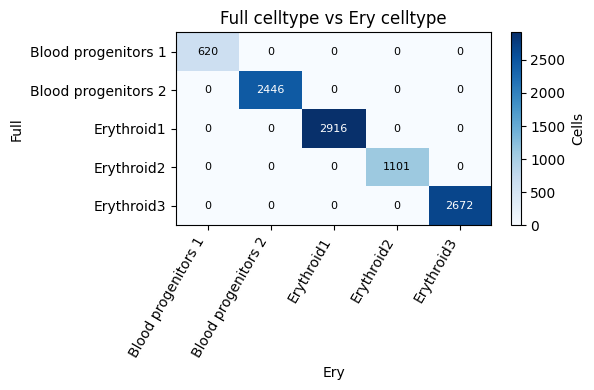

stage,E7.0,E7.25,E7.5,E7.75,E8.0,E8.25,E8.5
stage,,,,,,,
E7.0,43,0,0,0,0,0,0
E7.25,0,65,0,0,0,0,0
E7.5,0,0,469,0,0,0,0
E7.75,0,0,0,1708,0,0,0
E8.0,0,0,0,0,2793,0,0
E8.25,0,0,0,0,0,1688,0
E8.5,0,0,0,0,0,0,2989


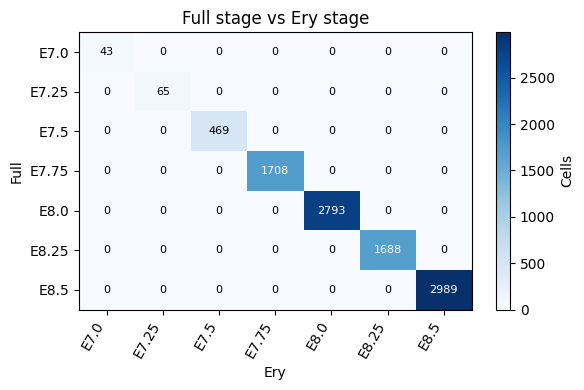

celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
cluster.sub,,,,,
1.0,0,1710,0,0,451
2.0,0,519,0,0,754
3.0,444,0,0,1101,783
4.0,176,0,584,0,501
5.0,0,0,873,0,183
6.0,0,217,0,0,0
7.0,0,0,836,0,0
8.0,0,0,623,0,0


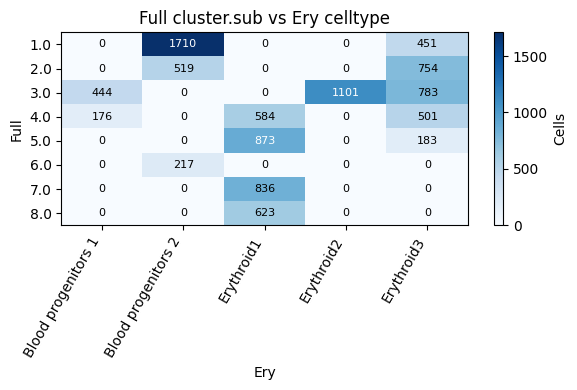

celltype,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
haem_subclust,,,,,
BP1,23,898,1,0,0
BP2,0,1283,716,0,0
BP3,0,92,1,0,0
BP4,7,46,0,0,0
EC3,7,0,0,0,0
Ery1,0,1,1928,20,0
Ery2,0,0,270,1055,152
Ery3,0,0,0,5,1276
Ery4,0,0,0,21,1244


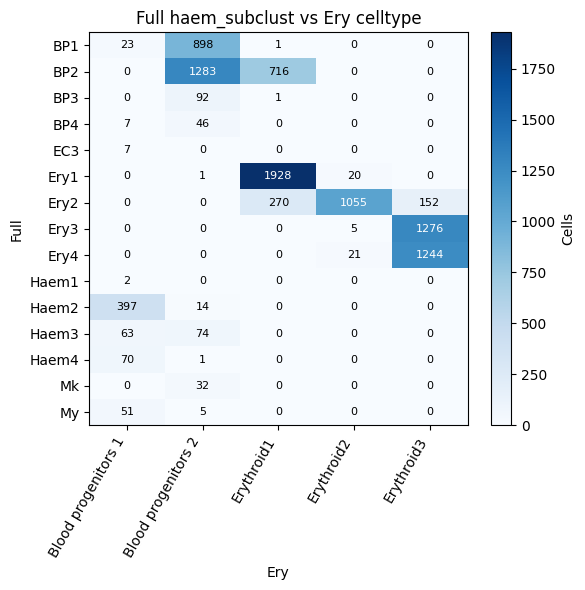

,matched_cells,comparable,matches,mismatches,one_missing,both_missing,agreement
column,,,,,,,
celltype,9755,9755,9755,0,0,0,1.0
stage,9755,9755,9755,0,0,0,1.0


In [5]:
verified_annotations = extra.annotations_after_matching(
    full, ery, expression_match, FIGURES, REPORTS)


## N. 保存済みPCA/UMAPの描画（10図）
`obsm['X_pca'][:, :2]`と`obsm['X_umap'][:, :2]`のみを使用します。Full/Eryの座標系が同一とは仮定しません。同名annotationの色は両datasetで揃え、凡例を図外に全件表示します。Full lineage強調図では他の細胞を灰色にし、haem_subclustの欠損も灰色で表示します。

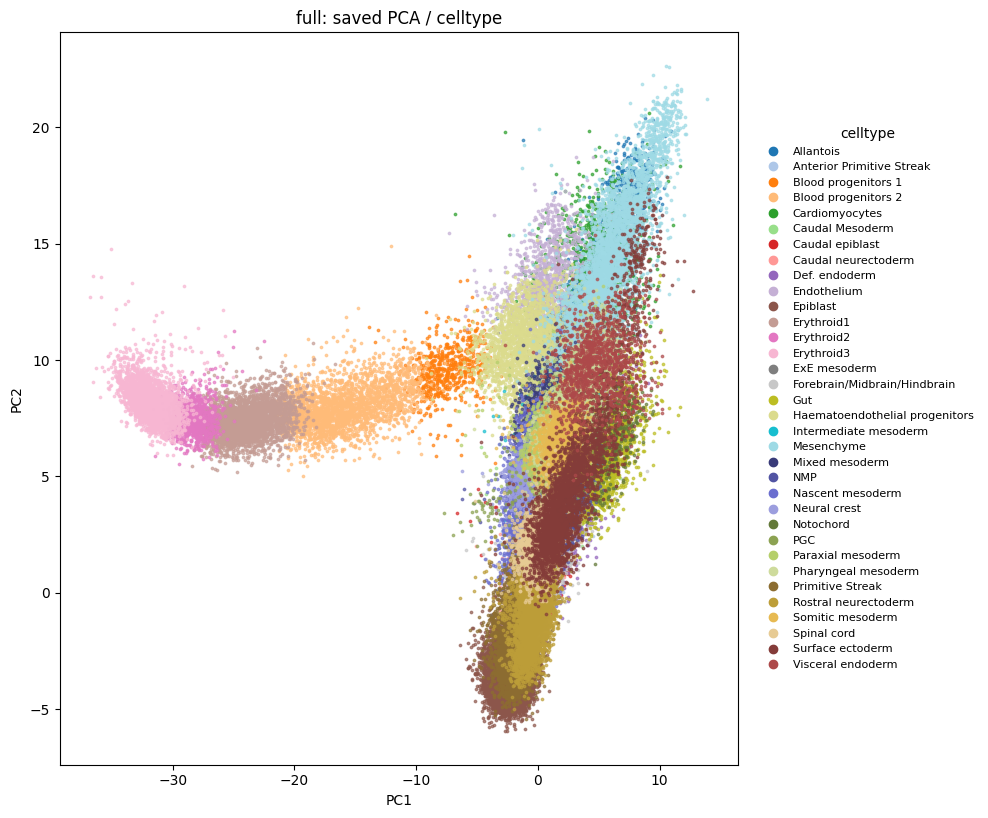

full_saved_pca_celltype.png ; cells with invalid coordinates: 0


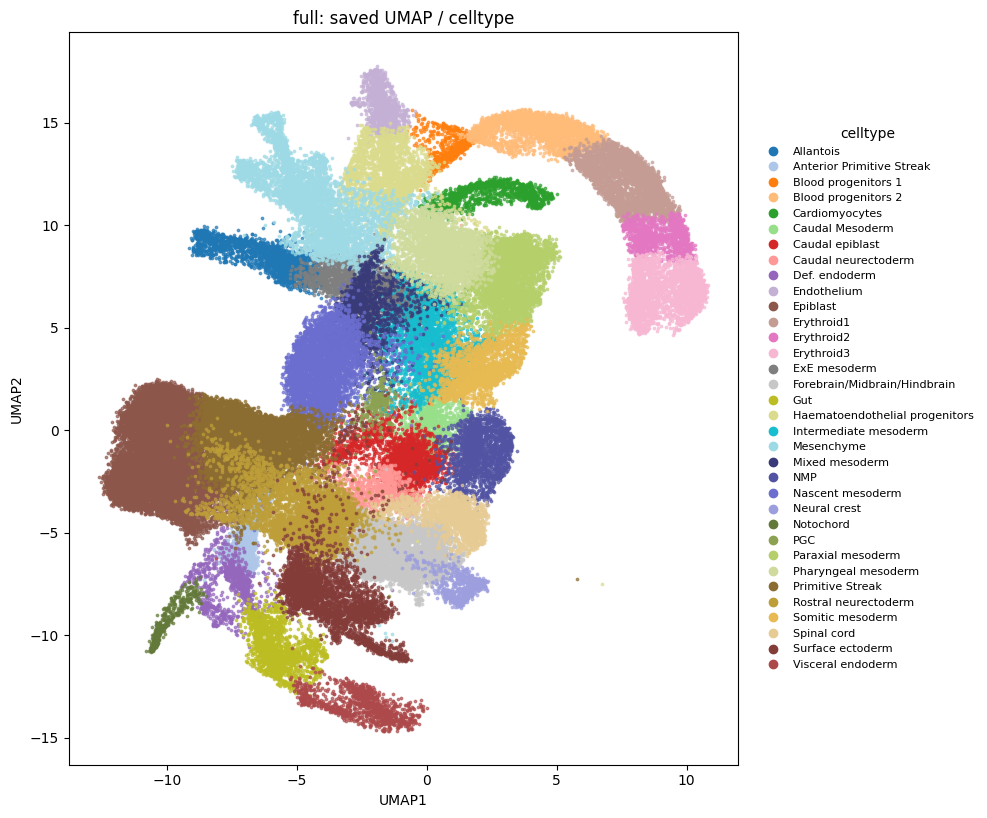

full_saved_umap_celltype.png ; cells with invalid coordinates: 0


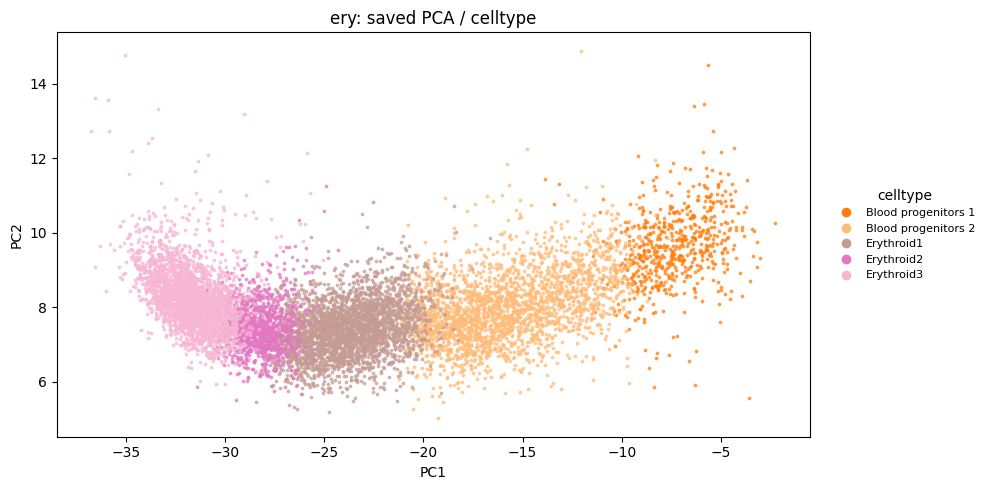

ery_saved_pca_celltype.png ; cells with invalid coordinates: 0


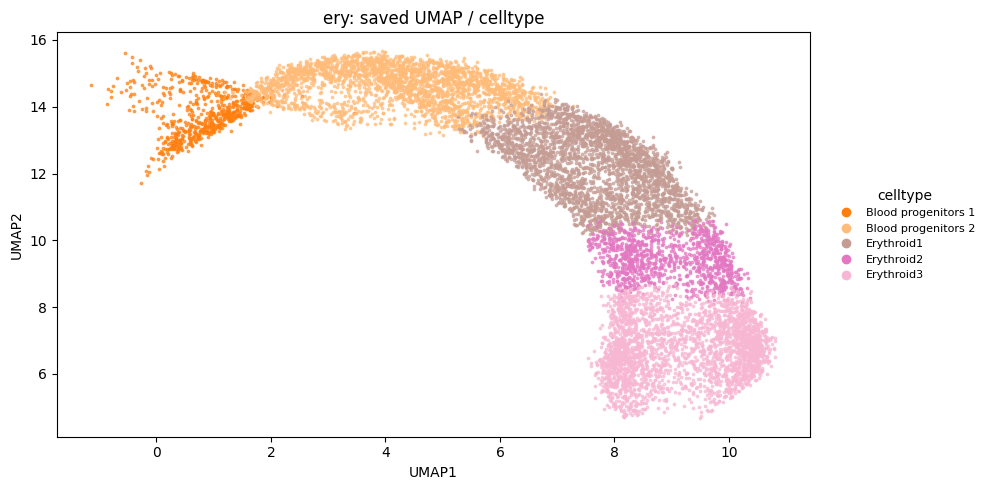

ery_saved_umap_celltype.png ; cells with invalid coordinates: 0


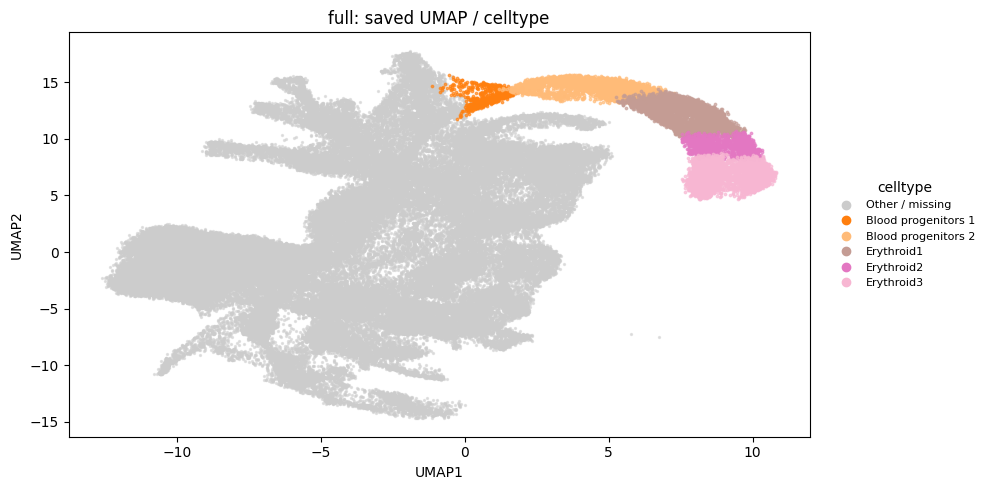

full_saved_umap_erythroid_lineage.png ; cells with invalid coordinates: 0


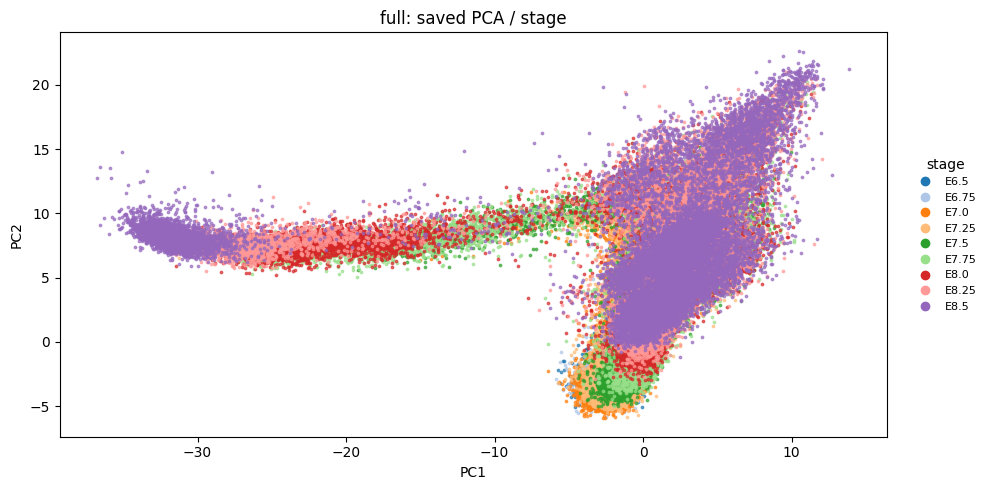

full_saved_pca_stage.png ; cells with invalid coordinates: 0


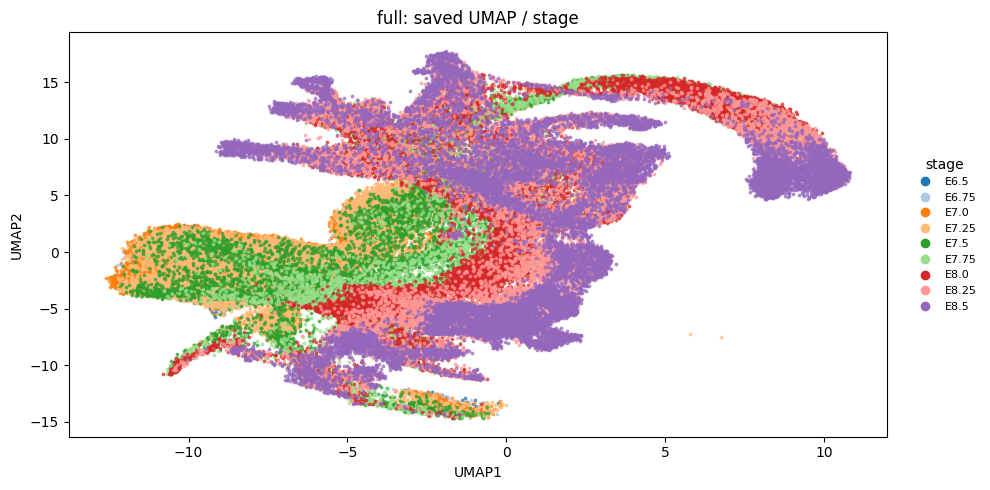

full_saved_umap_stage.png ; cells with invalid coordinates: 0


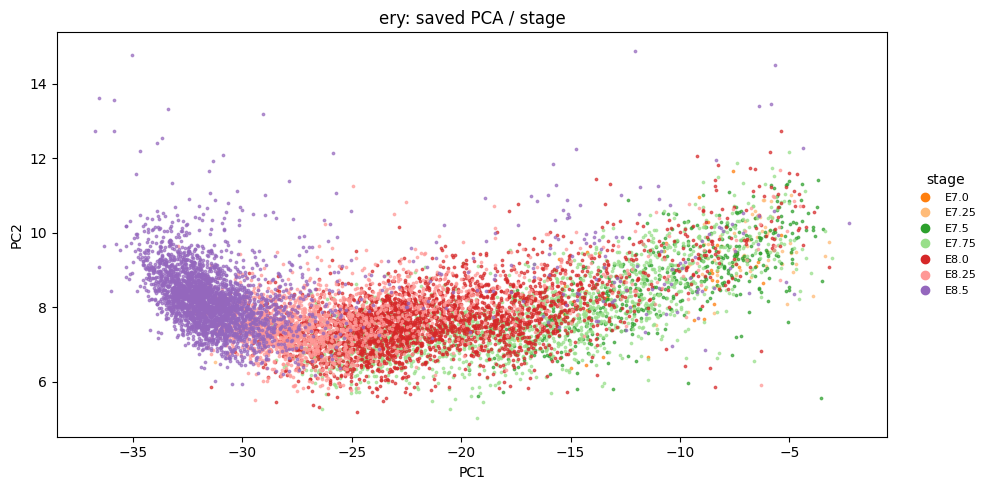

ery_saved_pca_stage.png ; cells with invalid coordinates: 0


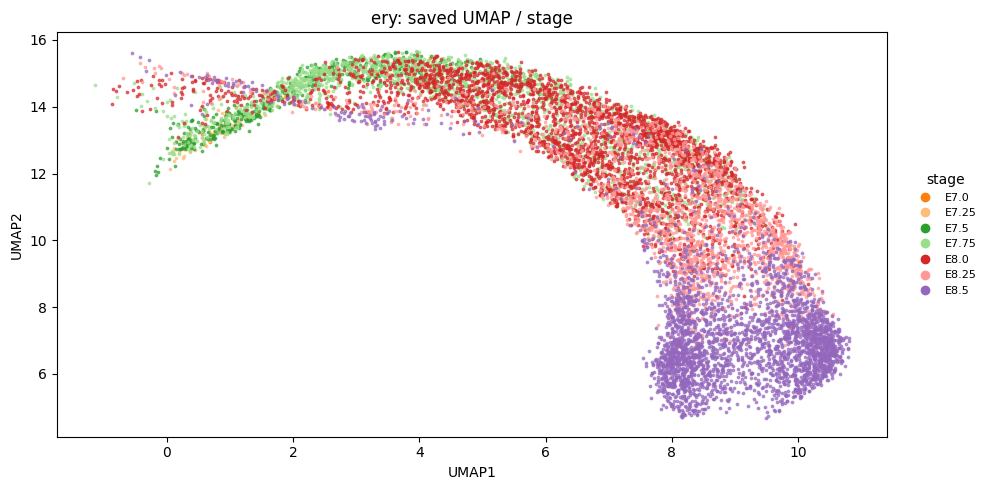

ery_saved_umap_stage.png ; cells with invalid coordinates: 0


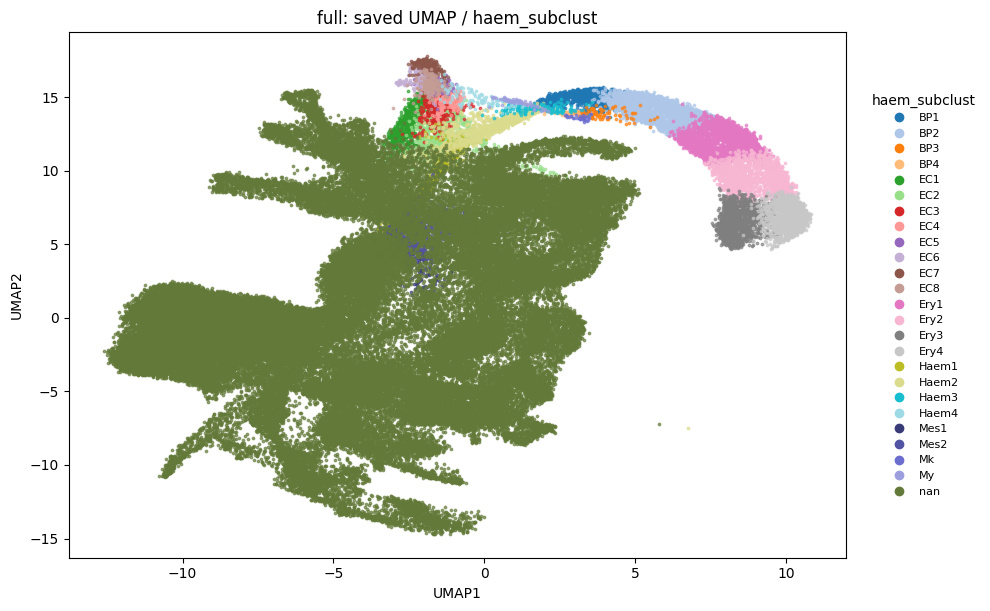

full_saved_umap_haem_subclust.png ; cells with invalid coordinates: 0


In [6]:
extra.plot_saved_embeddings(full, ery, FIGURES)


## O. dataset内部のmatrix完全一致
全cell×全geneを32行ずつsparse差分で検証します。平均絶対誤差の分母は暗黙のゼロを含む全要素数です。NaN/Infがある場合は個数を表示し完全一致を未確定とします。sample統計の一致とは区別してください。

In [7]:
internal_equality = extra.compare_internal_matrices(full, ery, REPORTS)


Checking all elements: full X spliced
Checking all elements: ery X spliced
Checking all elements: ery X raw_counts
Checking all elements: ery spliced raw_counts


,dataset,left,right,status,elements_checked,finite_different_elements,nonfinite_locations,different_elements,max_absolute_error,mean_absolute_error,exact_equal
0,full,X,spliced,checked_all_elements,4802653867,0,0,0,0.0,0.0,True
1,ery,X,spliced,checked_all_elements,528056815,0,0,0,0.0,0.0,True
2,ery,X,raw_counts,checked_all_elements,528056815,0,0,0,0.0,0.0,True
3,ery,spliced,raw_counts,checked_all_elements,528056815,0,0,0,0.0,0.0,True


## P. 前処理の事実・推定・未確認事項
library size、整数らしさ、nonzero率は既存diagnosticsを再利用します。kernel再起動後など未計算の場合だけ、Xと主要layersの統計を計算します。整数らしさはnonzero sampleに基づくため、raw countsの断定には使用しません。HVGをPCAのみに使った可能性や、metadataに残らない処理は否定できません。

In [8]:
additional_diagnostics = globals().get('diagnostics', {})
if not additional_diagnostics:
    additional_diagnostics = {}
    for name, adata in [('full', full), ('ery', ery)]:
        additional_diagnostics[name] = {}
        for key in ['X', 'spliced', 'unspliced', 'raw_counts']:
            mat = extra.matrix(adata, key)
            if mat is not None:
                print('Computing diagnostics:', name, key, flush=True)
                additional_diagnostics[name][key] = describe_matrix(mat)
preprocessing_check = extra.preprocessing_evidence(
    full, ery, additional_diagnostics, internal_equality, REPORTS)


Computing diagnostics: full X
Computing diagnostics: full spliced
Computing diagnostics: full unspliced
Computing diagnostics: ery X
Computing diagnostics: ery spliced
Computing diagnostics: ery unspliced
Computing diagnostics: ery raw_counts


,dataset,topic,observed,interpretation,unknown
0,full,X integer/count evidence,"{'min': 0, 'max': 4855.0, 'integer_like_fraction': 1.0, 'nonzero_sample_n': 100000, 'nonzero_fraction_finite': 0.055350982261408097, 'negative_count': 0, 'nonfinite_count': 0}",Sample and range support nonnegative integer counts; not proof of original raw counts.,"Nonzero integer fraction is sampled, not an exhaustive integer test."
1,full,X library-size normalization,"{'mean': 11799.990097124357, 'std': 4497.966217343802, 'min': 3676.0, 'max': 63680.0, 'CV': 0.3811838976407235}",Totals vary; no common fixed library total observed.,Variable totals do not exclude every normalization procedure.
2,full,spliced integer/count evidence,"{'min': 0, 'max': 4855.0, 'integer_like_fraction': 1.0, 'nonzero_sample_n': 100000, 'nonzero_fraction_finite': 0.055350982261408097, 'negative_count': 0, 'nonfinite_count': 0}",Sample and range support nonnegative integer counts; not proof of original raw counts.,"Nonzero integer fraction is sampled, not an exhaustive integer test."
3,full,spliced library-size normalization,"{'mean': 11799.990097124357, 'std': 4497.966217343802, 'min': 3676.0, 'max': 63680.0, 'CV': 0.3811838976407235}",Totals vary; no common fixed library total observed.,Variable totals do not exclude every normalization procedure.
4,full,unspliced integer/count evidence,"{'min': 0, 'max': 157.0, 'integer_like_fraction': 1.0, 'nonzero_sample_n': 100000, 'nonzero_fraction_finite': 0.009442716517967211, 'negative_count': 0, 'nonfinite_count': 0}",Sample and range support nonnegative integer counts; not proof of original raw counts.,"Nonzero integer fraction is sampled, not an exhaustive integer test."
5,full,unspliced library-size normalization,"{'mean': 713.3944794828997, 'std': 303.3402485730778, 'min': 72.0, 'max': 3565.0, 'CV': 0.42520689085364444}",Totals vary; no common fixed library total observed.,Variable totals do not exclude every normalization procedure.
6,full,log1p,'absent',Integer-like X samples support an unlogged count representation.,Missing log1p metadata alone does not prove no historical log transform.
7,full,gene filtering / HVG subset,"n_vars=53801; var columns=['Accession', 'Chromosome', 'End', 'Start', 'Strand']",Not a 1000–3000-gene HVG subset.,Original gene universe and upstream gene filtering; PCA may use selected genes without subsetting AnnData.
8,full,saved embeddings,"{'X_pca': (89267, 50), 'X_umap': (89267, 2)}",Embeddings already exist where listed.,Cannot conclude only PCA/UMAP was done; their input matrix and preprocessing history are unknown.
9,ery,X integer/count evidence,"{'min': 0, 'max': 4855.0, 'integer_like_fraction': 1.0, 'nonzero_sample_n': 100000, 'nonzero_fraction_finite': 0.05180267392250207, 'negative_count': 0, 'nonfinite_count': 0}",Sample and range support nonnegative integer counts; not proof of original raw counts.,"Nonzero integer fraction is sampled, not an exhaustive integer test."


Exhaustive within-dataset equality evidence:


,dataset,left,right,status,elements_checked,finite_different_elements,nonfinite_locations,different_elements,max_absolute_error,mean_absolute_error,exact_equal
0,full,X,spliced,checked_all_elements,4802653867,0,0,0,0.0,0.0,True
1,ery,X,spliced,checked_all_elements,528056815,0,0,0,0.0,0.0,True
2,ery,X,raw_counts,checked_all_elements,528056815,0,0,0,0.0,0.0,True
3,ery,spliced,raw_counts,checked_all_elements,528056815,0,0,0,0.0,0.0,True


## Q. 116,312 cellsと89,267 cellsの差: 確認済み範囲
[元論文](https://www.nature.com/articles/s41586-019-0933-9)はatlas全体の116,312細胞を報告しています。一方、既存Notebookで今回のFullは89,267細胞でした。差は27,045ですが、具体的な除外理由はこの情報だけでは確定できません。

[scVelo v0.3.3](https://github.com/theislab/scvelo/blob/v0.3.3/scvelo/datasets/_datasets.py)と[v0.3.4](https://github.com/theislab/scvelo/blob/v0.3.4/scvelo/datasets/_datasets.py)のgastrulation loaderは[Figshare file 28095525](https://ndownloader.figshare.com/files/28095525)を読み、var_namesを一意化して返します。loader本体にはcell filterがありません。本ディレクトリのdownload_data.pyも戻り値を追加filterせず保存します。既存READMEの『full』は呼称であり、原論文の全細胞を含むことの保証ではありません。

[benchmark README](https://github.com/edawu11/Benchmark-RNA-Velocity#-dataset-information)はData 3の元データ取得方法としてgastrulation_erythroidを挙げ、processed版はZenodoで配布しています。今回のEryはそのprocessed版です。公開説明とloaderから、Figshareファイルを作成するまでの具体的なcell選別過程は確認できていません。QC、doublet除去、velocity対象cellとの交差などを原因と断定しません。

以下で取得時のfull_source.json、現在kernelのloader source、保存前cacheのshapeを表示します。cacheが89,267細胞なら、差は今回の保存処理より前に存在したことを確認できます。loader呼び出し・ダウンロードは行いません。

In [9]:
extra.provenance(DATA, full)


Current kernel packages: {'anndata': '0.8.0', 'scanpy': '1.9.3', 'scvelo': '0.3.3', 'numpy': '1.26.4', 'scipy': '1.13.1', 'pandas': '2.3.3', 'matplotlib': '3.9.4'}
Download-time provenance: {'loader': 'scvelo.datasets.gastrulation', 'scvelo_version': '0.3.4', 'note': 'Saved returned object; loader may make var_names unique.'}
Installed scVelo loader source (not executed):
def gastrulation(
    file_path: Optional[Union[str, Path]] = "data/Gastrulation/gastrulation.h5ad"
):
    """Mouse gastrulation.

    Data from :cite:p:`PijuanSala19`.

    Gastrulation represents a key developmental event during which embryonic pluripotent
    cells diversify into lineage-specific precursors that will generate the adult
    organism.

    This data contains the erythrocyte lineage from Pijuan-Sala et al. (2019).
    The experiment reveals the molecular map of mouse gastrulation and early
    organogenesis. It comprises transcriptional profiles of 116,312 single cells from
    mouse embryos collected

## R. 追加解析summary
数値は今回の計算結果だけから作ります。完全一致細胞数は全検証matrixに一致する候補があるEry細胞数（一意でない例を含む）。一意対応数は多対一やゼロだけの候補を除外した数です。annotationの採用、転記や追加前処理は行いません。

In [10]:
additional_summary = extra.final_summary(
    full, ery, barcode_check, expression_match, lineage_check,
    verified_annotations, internal_equality, additional_diagnostics)
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(additional_summary)
additional_summary.to_csv(REPORTS / 'additional_summary.csv', index=False)


,項目,結果
0,Full cell count,89267
1,Erythroid cell count,9815
2,Fullの5 celltype抽出数,9815
3,Barcode一致率,0.993887
4,一意に対応できた細胞数,9755
5,発現量完全一致の細胞数（候補あり・曖昧例を含む）,9755
6,検証した共通gene数,53801
7,検証matrix,"[X, spliced, unspliced]"
8,celltype一致率（双方nonmissing）,1.0
9,stage一致率（双方nonmissing）,1.0


## S. Mouse GRNとgastrulationの遺伝子名: 形式・重複・欠損
既存セルで読み込まれた`full`のvar metadataのみを使用します。X/layersにはアクセスせず、遺伝子名・元データは変更しません。以下のS–Uを順に実行してください。

Ensembl形式（mouse gene: ENSMUSG＋数字、任意のversion suffix）とsymbolらしい形式を区別します。正規表現による形式推定であり、公式symbolとしての有効性・alias対応の証明ではありません。欠損、空文字/空白のみ、重複の余分な行数と重複値数を分けて表示します。

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

if 'full' not in globals():
    raise RuntimeError('先頭のセットアップセルでfullを読み込んでから実行してください。')
print('full.var_names first 20:', full.var_names[:20].tolist())
print('full.var.columns:', full.var.columns.tolist())
display(full.var.head(20))
grn_candidates = {'var_names': pd.Series(full.var_names, dtype='string')}
if 'Accession' in full.var:
    print('full.var[Accession] first 20:')
    display(full.var['Accession'].head(20))
    grn_candidates['Accession'] = full.var['Accession'].reset_index(drop=True).astype('string')
else:
    print('Accession列なし: この候補は未評価とします。')

def grn_valid_names(values):
    values = pd.Series(values, dtype='string').reset_index(drop=True)
    # Exclude missing/empty identifiers only; do not trim, change case, or remove suffixes.
    return values[values.notna() & ~values.str.fullmatch(r'\s*', na=False)]

def grn_name_profile(values):
    values = pd.Series(values, dtype='string').reset_index(drop=True)
    valid = grn_valid_names(values)
    mouse_ensembl = valid.str.fullmatch(r'ENSMUSG[0-9]+(?:\.[0-9]+)?', na=False)
    other_ensembl = valid.str.fullmatch(r'ENS[A-Z]*[GTP][0-9]+(?:\.[0-9]+)?', na=False) & ~mouse_ensembl
    symbol_like = valid.str.fullmatch(r'[A-Za-z][A-Za-z0-9_.-]*', na=False) & ~mouse_ensembl & ~other_ensembl
    if not len(valid):
        inferred = '判定不可（有効値なし）'
    elif mouse_ensembl.all():
        inferred = 'mouse Ensembl gene ID形式'
    elif symbol_like.all():
        inferred = 'gene symbolらしい形式（公式symbol未検証）'
    else:
        inferred = '混在またはその他のID形式: 下記件数を参照'
    return {'rows': len(values), 'unique_valid_names': valid.nunique(),
            'missing_rows': int(values.isna().sum()),
            'blank_rows': int(values.str.fullmatch(r'\s*', na=False).sum()),
            'duplicate_extra_rows': int(valid.duplicated().sum()),
            'duplicate_name_values': int((valid.value_counts() > 1).sum()),
            'mouse_ensembl_rows': int(mouse_ensembl.sum()),
            'other_ensembl_rows': int(other_ensembl.sum()),
            'symbol_like_rows': int(symbol_like.sum()),
            'other_format_rows': int((~(mouse_ensembl | other_ensembl | symbol_like)).sum()),
            'inferred_format': inferred}

grn_name_profiles = pd.DataFrame({name: grn_name_profile(values)
                                  for name, values in grn_candidates.items()}).T
with pd.option_context('display.max_columns', None, 'display.max_colwidth', None):
    display(grn_name_profiles)
for name, values in grn_candidates.items():
    print(name, 'duplicate examples:')
    counts = grn_valid_names(values).value_counts()
    display(counts[counts > 1].head(20))


## T. GRN遺伝子・エッジ保持率: 完全一致と参考値
既存BASEからリポジトリ直下の`external_data/Mouse_tf_target_edges.tsv`を解決します。必要なfrom/to列のみ読みます。ODEの`from.isin(full_set) & to.isin(full_set)`と同じcase-sensitive条件でエッジ保持率を計算します。欠損・空白だけのIDは有効遺伝子集合から除外し、元の文字列はstrip・大文字化・suffix除去しません。

遺伝子一致率の分母は有効なユニークID数です。from/to別一致率は各端点集合を分母とします。エッジの方向は維持し、自己ループも除外しません。全エッジ率はTSV行数、ユニークエッジ率はfrom/toペアの重複除去後の全行数を分母とし、無効端点の行も分母に残します。

case-insensitiveのcasefoldはコピーした集合上でのみ行い、完全一致の保持エッジや最終判断に混ぜません。casefold前後のユニーク数・衝突数を示し、元のID単位のカバレッジとfold後集合のカバレッジを区別します。

In [ ]:
grn_base = Path(BASE) if 'BASE' in globals() else Path('/home/suzuki/Projects/scDiffusion-github/data_preparation/20261007')
grn_path = grn_base.resolve().parents[1] / 'external_data' / 'Mouse_tf_target_edges.tsv'
if not grn_path.is_file():
    raise FileNotFoundError(f'Mouse GRN TSVが見つかりません: {grn_path}')
print('GRN file:', grn_path)
# Same column selection/parser defaults as the ODE loader. No expression access.
grn_edges = pd.read_csv(grn_path, sep='\t', usecols=['from', 'to'])
grn_from = set(grn_valid_names(grn_edges['from']))
grn_to = set(grn_valid_names(grn_edges['to']))
grn_union = grn_from | grn_to
grn_unique_edges = grn_edges.drop_duplicates(subset=['from', 'to'])
display(pd.DataFrame({col: grn_name_profile(grn_edges[col]) for col in ['from', 'to']}).T)
print('TSV rows:', len(grn_edges), '; directed unique edges:', len(grn_unique_edges))

def grn_percent(numerator, denominator):
    return 100.0 * numerator / denominator if denominator else float('nan')

grn_exact_records, grn_ci_records = [], []
for name, values in grn_candidates.items():
    valid = grn_valid_names(values)
    genes = set(valid)
    shared = genes & grn_union
    edge_mask = grn_edges['from'].isin(genes) & grn_edges['to'].isin(genes)
    retained = grn_edges.loc[edge_mask, ['from', 'to']]
    retained_unique = retained.drop_duplicates(subset=['from', 'to'])
    participants = set(retained['from']) | set(retained['to'])
    grn_exact_records.append({
        'candidate': name, 'full_unique_genes': len(genes), 'tsv_unique_genes': len(grn_union),
        'common_genes': len(shared), 'common/full_%': grn_percent(len(shared), len(genes)),
        'common/tsv_%': grn_percent(len(shared), len(grn_union)),
        'from_unique_genes': len(grn_from), 'from_common': len(genes & grn_from),
        'from_coverage_%': grn_percent(len(genes & grn_from), len(grn_from)),
        'to_unique_genes': len(grn_to), 'to_common': len(genes & grn_to),
        'to_coverage_%': grn_percent(len(genes & grn_to), len(grn_to)),
        'tsv_edges': len(grn_edges), 'retained_edges': len(retained),
        'edge_retention_%': grn_percent(len(retained), len(grn_edges)),
        'tsv_unique_edges': len(grn_unique_edges), 'retained_unique_edges': len(retained_unique),
        'unique_edge_retention_%': grn_percent(len(retained_unique), len(grn_unique_edges)),
        'participating_unique_genes': len(participants),
        'participating/full_unique_%': grn_percent(len(participants), len(genes)),
        'participating_var_rows': int(values.isin(participants).sum()),
        'participating/full_var_rows_%': grn_percent(int(values.isin(participants).sum()), len(values)),
    })
    print('\nExact-match examples:', name)
    for label, ids in [('shared', shared), ('full_only', genes - grn_union),
                       ('GRN_only', grn_union - genes), ('from_shared', genes & grn_from),
                       ('from_unmatched', grn_from - genes), ('to_shared', genes & grn_to),
                       ('to_unmatched', grn_to - genes)]:
        print(label, '(up to 20):', sorted(ids)[:20])
    print('Retained edge examples:'); display(retained.head(20))

    folded_full = {gene.casefold() for gene in genes}
    folded_tsv = {gene.casefold() for gene in grn_union}
    folded_common = folded_full & folded_tsv
    grn_ci_records.append({
        'candidate': name, 'full_folded_unique': len(folded_full), 'tsv_folded_unique': len(folded_tsv),
        'full_case_collisions': len(genes) - len(folded_full),
        'tsv_case_collisions': len(grn_union) - len(folded_tsv),
        'folded_common': len(folded_common),
        'folded_common/full_folded_%': grn_percent(len(folded_common), len(folded_full)),
        'folded_common/tsv_folded_%': grn_percent(len(folded_common), len(folded_tsv)),
        'full_original_IDs_covered_%': grn_percent(sum(g.casefold() in folded_tsv for g in genes), len(genes)),
        'tsv_original_IDs_covered_%': grn_percent(sum(g.casefold() in folded_full for g in grn_union), len(grn_union)),
        'from_original_IDs_covered_%': grn_percent(sum(g.casefold() in folded_full for g in grn_from), len(grn_from)),
        'to_original_IDs_covered_%': grn_percent(sum(g.casefold() in folded_full for g in grn_to), len(grn_to)),
    })

grn_exact_comparison = pd.DataFrame(grn_exact_records).set_index('candidate')
grn_case_insensitive_reference = pd.DataFrame(grn_ci_records).set_index('candidate')
with pd.option_context('display.max_columns', None, 'display.width', 240):
    print('CASE-SENSITIVE EXACT MATCH — ODE-compatible edge condition; percentages in %')
    display(grn_exact_comparison)
    print('CASE-INSENSITIVE REFERENCE ONLY — not used for edge retention or recommendation')
    display(grn_case_insensitive_reference)


## U. ODEへの遺伝子名入力候補: 調査summary
完全一致で利用できるユニークエッジ数を第一基準、参加gene数・共通gene数を補助基準に候補を比較します。同点なら既存var_namesを優先する旨を明示します。ただし、入力の欠損・空白・重複がある候補は、そのまま安全に渡せる候補とはしません。値の置換・ID変換・GRNの書き出し・学習は一切行いません。

『GRNに名前があるgene』と『両端が揃った保持エッジに参加できるgene』を区別します。一部の未一致geneが存在するだけでID変換が必須とは判断せず、既存GRNの収録範囲・alias等の未確認事項を残します。

In [ ]:
grn_safe_candidates = [name for name in grn_candidates
                       if all(grn_name_profiles.loc[name, col] == 0
                              for col in ['missing_rows', 'blank_rows', 'duplicate_extra_rows'])
                       and grn_exact_comparison.loc[name, 'retained_unique_edges'] > 0]
if grn_safe_candidates:
    def grn_candidate_score(name):
        row = grn_exact_comparison.loc[name]
        return (row['retained_unique_edges'], row['participating_unique_genes'], row['common_genes'])
    best_score = max(grn_candidate_score(name) for name in grn_safe_candidates)
    tied = [name for name in grn_safe_candidates if grn_candidate_score(name) == best_score]
    grn_preferred = 'var_names' if 'var_names' in tied else tied[0]
    selected = grn_exact_comparison.loc[grn_preferred]
    reason = '有効な候補の中で、完全一致のユニーク保持エッジ数・参加gene数を優先。'
    if len(tied) > 1:
        reason += ' 指標は同点のため、既存のvar_namesを優先。'
    recommendation = f'{grn_preferred}が適切な入力候補。{reason}'
    conversion = ('この完全一致GRNの利用にID変換は不要。未一致geneは収録範囲やalias等を別途確認。'
                  if grn_preferred == 'var_names' else
                  '既存Accessionを発現列と同じ順序で入力gene listに使うなら、新しいID変換は不要。var_namesで照合する場合の変換要否は別途検討。')
    gene_coverage = (f"{selected['common/full_%']:.2f}%（名前がGRNに含まれる / 有効unique gene）、"
                     f"{selected['participating/full_unique_%']:.2f}%（保持エッジに参加 / 有効unique gene）、"
                     f"{selected['participating/full_var_rows_%']:.2f}%（参加する発現列 / 全var行）")
    edge_coverage = (f"{selected['edge_retention_%']:.2f}%（全TSV行）、"
                     f"{selected['unique_edge_retention_%']:.2f}%（重複除去後の有向エッジ）")
else:
    grn_preferred = None
    recommendation = '現状、そのまま利用可能と判断できる候補なし。完全一致エッジ数と欠損・重複を確認。'
    conversion = 'ID変換が必要かは未確定。ID体系・GRNの収録範囲・欠損・重複を確認する必要がある。'
    gene_coverage = '候補未選択。候補別の完全一致比較表を参照。'
    edge_coverage = '候補未選択。候補別の完全一致比較表を参照。'
grn_summary = pd.DataFrame([
    ('1. ODE入力候補', recommendation),
    ('2. Full geneのGRNカバレッジ', gene_coverage),
    ('3. 使用可能なGRNエッジ', edge_coverage),
    ('4. ID変換の必要性', conversion),
], columns=['項目', '結果'])
with pd.option_context('display.max_colwidth', None, 'display.max_columns', None):
    display(grn_exact_comparison)
    display(grn_summary)
print('調査のみ: 遺伝子名の変更・ID変換・発現行列アクセス・学習は行っていません。')
